In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
%cd /content/drive/MyDrive/AI_and_ML_reading_material/Interpretability_in_wild

In [ ]:
%pwd

In [ ]:
%pip install transformer_lens==2.11.0 einops jaxtyping plotly-utils git+https://github.com/callummcdougall/CircuitsVis.git#subdirectory=python

# Interpretability in the Wild: a Circuit for Indirect Object Identification in GPT-2 Small
 <h1><b>Intro</b></h1>
 This notebook implements all experiments in the paper.
 For background on the task, see the paper.


 Reminder of the circuit:
 <img src="https://i.imgur.com/arokEMj.png">

## Setup

You can add the current directory to your Python path to make its modules importable. Since you've already navigated to the folder with `!cd`, we can use `os.getcwd()` to get the current path and add it to `sys.path`.

Now you should be able to import modules from `.py` files located directly in `/content/drive/MyDrive/.../Interpretability_in_wild` or its subdirectories (provided they are proper Python packages with `__init__.py` files if nested).

In [ ]:
import os
import sys

# Get the current working directory (where your .py files are located)
current_directory = os.getcwd()

# Add the current directory to sys.path
if current_directory not in sys.path:
    sys.path.append(current_directory)
    print(f"Added '{current_directory}' to sys.path.")
else:
    print(f"'{current_directory}' is already in sys.path.")

# You can verify by printing sys.path
# print(sys.path)

In [ ]:
import transformer_lens
import re
import sys
from functools import partial
from itertools import product
from pathlib import Path
from typing import Callable, Literal, Tuple

import circuitsvis as cv
import einops
import numpy as np
import plotly.express as px
import torch as t
from IPython.display import HTML, display
from jaxtyping import Bool, Float, Int
from rich import print as rprint
from rich.table import Column, Table
from torch import Tensor
from tqdm.notebook import tqdm
from transformer_lens import ActivationCache, HookedTransformer, utils
from transformer_lens.components import MLP, Embed, LayerNorm, Unembed
from transformer_lens.hook_points import HookPoint

t.set_grad_enabled(False)
device = t.device(
    "mps" if t.backends.mps.is_available() else "cuda" if t.cuda.is_available() else "cpu"
)

from plotly.express import bar, imshow, line, scatter

MAIN = __name__ == "__main__"

# Model Setup


In [ ]:
model = HookedTransformer.from_pretrained(
    "gpt2-small",
    center_unembed=True, # this sets the mean of the unembedding matrix to zero.
    center_writing_weights=True, # Whether to center weights writing to the residual stream (ie set mean to be zero). Due to LayerNorm this doesn’t change the computation.
    fold_ln=True,
    refactor_factored_attn_matrices=True,
)

<details>
<summary>Note on <code>refactor_factored_attn_matrices</code> </summary>

This argument means we redefine the matrices $W_Q$, $W_K$, $W_V$ and $W_O$ in the model (without changing the model's actual behaviour).

For example, we know that instead of working with $W_Q$ and $W_K$ individually, the only matrix we actually need to use in the model is the low-rank matrix $W_Q W_K^T$ (note that I'm using the convention of matrix multiplication on the right, which matches the code in transformerlens and previous exercises in this series, but doesn't match Anthropic's Mathematical Frameworks paper). So if we perform singular value decomposition $W_Q W_K^T = U S V^T$, then we see that we can just as easily define $W_Q = U \sqrt{S}$ and $W_K = V \sqrt{S}$ and use these instead. This means that $W_Q$ and $W_K$ both have orthogonal columns with matching norms. You can investigate this yourself (e.g. using the code below). This is arguably a more interpretable setup, because now there's no obvious asymmetry between the keys and queries.

There's also some fiddlyness with how biases are handled in this factorisation, which is why the comments above don't hold absolutely (see the documentation for more info).

```python
# Show column norms are the same (except first few, for fiddly bias reasons)
line([model.W_Q[0, 0].pow(2).sum(0), model.W_K[0, 0].pow(2).sum(0)])
# Show columns are orthogonal (except first few, again)
W_Q_dot_products = einops.einsum(
    model.W_Q[0, 0], model.W_Q[0, 0], "d_model d_head_1, d_model d_head_2 -> d_head_1 d_head_2"
)
imshow(W_Q_dot_products)
```

In a similar way, since $W_{OV} = W_V W_O = U S V^T$, we can define $W_V = U S$ and $W_O = V^T$. This is arguably a more interpretable setup, because now $W_O$ is just a rotation, and doesn't change the norm, so $z$ has the same norm as the result of the head.
</details>

<details>
<summary>Note on <code>fold_ln</code>, <code>center_unembed</code> and <code>center_writing_weights</code> </summary>

`fold_ln=True` means “absorb (fold) LayerNorm into the surrounding linear weights so LayerNorm disappears as an explicit operation. TransformerLens:
1) Removes LayerNorm modules from the forward pass
2) Pushes their effect into adjacent weights
    * Q, K, V matrices
    * MLP weights
    * unembedding matrix

3) Rewrites the model so that
    * the residual stream is already “LN-normalized”
    * all remaining operations are linear + softmax

The model’s outputs are identical (up to floating-point noise).

See link [here](https://github.com/neelnanda-io/TransformerLens/blob/main/further_comments.md#what-is-layernorm-folding-fold_ln) for comments.
</details>


In [ ]:
# Here is where we test on a single prompt
# Result: 70% probability on Mary, as we expect

example_prompt = "After John and Mary went to the store, John gave a bottle of milk to"
example_answer = " Mary"
utils.test_prompt(example_prompt, example_answer, model, prepend_bos=True)

We'll run the model on 4 instances of this task, each prompt given twice - one with the first name as the indirect object, one with the second name. To make our lives easier, we'll carefully choose prompts with single token names and the corresponding names in the same token positions.

In [ ]:
prompt_format = [
    "When John and Mary went to the shops,{} gave the bag to",
    "When Tom and James went to the park,{} gave the ball to",
    "When Dan and Sid went to the shops,{} gave an apple to",
    "After Martin and Amy went to the park,{} gave a drink to",
]
# [A] -> [B]
name_pairs = [
    (" Mary", " John"),
    (" Tom", " James"),
    (" Dan", " Sid"),
    (" Martin", " Amy"),
]

# Create the set of input sentences. They should look like
# When John and Mary went to the shops,{} gave the bag to -> When John and Mary went to the shops, John gave the bag to
input_sentences, correct_answers, incorrect_answers = [], [], []
for prompt, (name1, name2) in zip(prompt_format, name_pairs):
    # [A] -> [B]
    input_sentences.append(prompt.format(name1))
    correct_answers.append(name2)
    incorrect_answers.append(name1)
    # [B] -> [A]
    input_sentences.append(prompt.format(name2))
    correct_answers.append(name1)
    incorrect_answers.append(name2)

rprint(input_sentences)
rprint(correct_answers)
rprint(incorrect_answers)

# Collect the token_ids of the correct and wrong answers. THe shape will be (total_sentences/batch, 2)
# This is to keep these ids in agreement with the kind of input required in subsequent functions.
subject_tokens = [[model.to_tokens(corr), model.to_tokens(incorr)] for (corr, incorr) in zip(correct_answers, incorrect_answers)]

table = Table("Prompt", "Correct", "Incorrect", title="Prompts & Answers:")
for prompt, correct, incorrect in zip(input_sentences, correct_answers, incorrect_answers):
    table.add_row(prompt, correct, incorrect)
rprint(table)

We now run the model on these prompts and use `run_with_cache` to get both the logits and a cache of all internal activations for later analysis.
* If `return_cache_object` is True, this will return an ActivationCache object, with a bunch of useful HookedTransformer specific methods, otherwise it will return a dictionary of activations as in HookedRootModule. Default is True.
*
        

In [ ]:
tokens = model.to_tokens(input_sentences, prepend_bos=True)
# Move the tokens to the GPU
tokens = tokens.to(device)
# Run the model and cache all activations of all layers.
original_logits, cache = model.run_with_cache(tokens)

We'll later be evaluating how model performance differs upon performing various interventions, so it's useful to have a metric to measure model performance. Our metric here will be the **logit difference**, the difference in logit between the indirect object's name and the subject's name (eg, `logit(Mary) - logit(John)`).

## Logit Difference

In [ ]:
def logit_diff(
    logits: Float[Tensor, "batch seq d_vocab"],
    answer_tokens: Int[Tensor, "batch 2"],
    per_prompt: bool = False
) -> Float[Tensor, "batch"]:
    """
    Calculates the difference between the logits of two answer tokens for each prompt. IO - S

    Args:
        logits (Float[Tensor, "{batch, seq, d_vocab}"]): The logits output by the model.
        answer_tokens (Int[Tensor, "{batch, 2}"]): A tensor where each row contains
            the token IDs for the correct answer and the incorrect answer, respectively.
        per_prompt (bool, optional): If True, returns the logit difference for each prompt.
            If False, returns the mean logit difference across all prompts. Defaults to False.

    Returns:
        Float[Tensor, "{batch}"]: A tensor containing the logit differences. If `per_prompt` is True,
            it's a 1D tensor with one difference per prompt. If `per_prompt` is False,
            it's a scalar tensor representing the mean difference.
    """
    # We only keep the logits for the token of the last position
    final_logits = logits[:, -1, :]
    # store the final position logit values for the two token IDS.
    logit_values = final_logits.gather(dim=-1, index=t.tensor(answer_tokens))
    # calculate the difference
    logit_diffs = logit_values[:, 0] - logit_values[:, 1]
    # Return array if per_prompt is True, else False
    if per_prompt:
        return logit_diffs
    else:
        return logit_diffs.mean()

In [ ]:
# Print the Logit differences

# Correctly format subject_tokens to be a tensor of scalar token IDs
subject_token_ids = []
for corr, incorr in zip(correct_answers, incorrect_answers):
    # model.to_tokens(string, prepend_bos=False) returns a tensor like [[token_id]]
    # .squeeze() converts [[token_id]] to token_id (a 0-dim tensor)
    correct_token_id = model.to_tokens(corr, prepend_bos=False).squeeze()
    incorrect_token_id = model.to_tokens(incorr, prepend_bos=False).squeeze()
    subject_token_ids.append([correct_token_id, incorrect_token_id])

# Convert the list of lists of token IDs into a single tensor of shape [batch, 2]
subject_tokens_formatted = t.tensor(subject_token_ids).to(device)

# Use the correctly formatted subject_tokens
original_per_prompt_diff = logit_diff(original_logits, subject_tokens_formatted, per_prompt=True)
print("Per prompt logit difference:", original_per_prompt_diff)
original_average_logit_diff = logit_diff(original_logits, subject_tokens_formatted)
print("Average logit difference:", original_average_logit_diff)

cols = [
    "Prompt",
    Column("Correct", style="rgb(0,200,0) bold"),
    Column("Incorrect", style="rgb(255,0,0) bold"),
    Column("Logit Difference", style="bold"),
]
table = Table(*cols, title="Logit differences")

for prompt, correct, incorrect, logit_diff_val in zip(input_sentences, correct_answers, incorrect_answers, original_per_prompt_diff):
    table.add_row(prompt, correct, incorrect, f"{logit_diff_val:.4f}")
rprint(table)


## Direct Logit Attribution

    How much does a particular internal component (head, neuron, layer output) directly contribute to a specific logit or logit difference?

The logits of a model are `logits=Unembed(LayerNorm(final_residual_stream))`. The Unembed is a linear map, and LayerNorm is approximately a linear map, so we can decompose the logits into the sum of the contributions of each component, and look at which components contribute the most to the logit of the correct token! This is called direct logit attribution. Here we look at the direct attribution to the logit difference!



### Logit difference directions

What we are trying to do here is finding out what vector from the $W_U$ matrix, acts on the embedding coming to the $W_U$ matrix. This will essentially tell what what direction do we need to nudge the residual stream to predict that particular token. Here we care about the vectors corresponding to the answer tokens



In [ ]:
answer_residual_directions = model.tokens_to_residual_directions(subject_tokens_formatted)
print("Answer residual directions shape:", answer_residual_directions.shape)
correct_residual_directions, incorrect_residual_directions = answer_residual_directions.unbind(
    dim=1
)
logit_diff_directions = (
    correct_residual_directions - incorrect_residual_directions
)  # [batch d_model]
print("Logit difference directions shape:", logit_diff_directions.shape)

The code below does the following:

* Gets the final residual stream values from the `cache` object (which you should already have defined above).
* Apply layernorm scaling to these values.
    * This is done by `cache.apply_to_ln_stack`, a helpful function which takes a stack of residual stream values (e.g. a batch, or the residual stream decomposed into components), treats them as the input to a specific layer, and applies the layer norm scaling of that layer to them.
    * The keyword arguments here indicate that our input is the residual stream values for the last sequence position, and we want to apply the final layernorm in the model.
* Project them along the unembedding directions (you've already defined these above, as `logit_diff_directions`).

In [ ]:
# Cache syntax: resid_post is the residual stream at the end of the layer, -1 gets the final layer.
# The general syntax is [activation_name, layer_index, sub_layer_type].
final_residual_stream: Float[Tensor, "batch seq d_model"] = cache["resid_post", -1]
print(f"Final residual stream shape: {final_residual_stream.shape}")
final_token_residual_stream: Float[Tensor, "batch d_model"] = final_residual_stream[:, -1, :]

# Apply LayerNorm scaling (to just the final sequence position)
# pos_slice is the subset of the positions we take - here the final token of each prompt
scaled_final_token_residual_stream = cache.apply_ln_to_stack(
    final_token_residual_stream, layer=-1, pos_slice=-1
)

# This means:
# For each batch element:
# take the dot product over d_model
# Then sum over the batch dimension
# Output is a scalar
average_logit_diff = einops.einsum(
    scaled_final_token_residual_stream, logit_diff_directions, "batch d_model, batch d_model ->"
) / len(input_sentences)

print(f"Calculated average logit diff: {average_logit_diff:.10f}")
print(f"Original logit difference:     {original_average_logit_diff:.10f}")

## Logit Lens

We can now decompose the residual stream! First we apply a technique called the [**logit lens**](https://www.alignmentforum.org/posts/AcKRB8wDpdaN6v6ru/interpreting-gpt-the-logit-lens) - this looks at the residual stream after each layer and calculates the logit difference from that. This simulates what happens if we delete all subsequence layers.

**A little about the** `ActivationCache` **class and** `apply_ln_to_stack`.

The `ActivationCache` is at the core of Transformer Lens. It is a wrapper that stores all
important activations from a forward pass of the model, and provides a variety of helper functions to investigate them. The common way to access it is to run the model with `transformer_lens.HookedTransformer.HookedTransformer.run_with_cache`.

The method `apply_ln_to_stack` takes a stack of components of the residual stream (eg outputs of decompose_resid or
        accumulated_resid), treats them as the input to a specific layer, and applies the layer norm
        scaling of that layer to them, using the cached scale factors - simulating what that
        component of the residual stream contributes to that layer's input.

        The layernorm scale is global across the entire residual stream for each layer, batch
        element and position, which is why we need to use the cached scale factors rather than just
        applying a new LayerNorm.

If the model does not use LayerNorm or RMSNorm, it returns the residual stack unchanged.

Here we will write a function which goes into the model and inspects each layer's activations. It will take in
* resiudal_stack which has residual states for each/particular model layer,
* a cache with all the activations of all layers.
* and a logit_diff_direction which tells the direction we are concerned with.

In [ ]:
def residual_stack_to_logit_diff(
    residual_stack: Float[Tensor, "... batch d_model"],
    cache: ActivationCache,
    logit_diff_directions: Float[Tensor, "batch d_model"] = logit_diff_directions,
) -> Float[Tensor, "..."]:
    """
    Calculates the logit difference from a given residual stream stack.

    This function takes a stack of residual stream components, applies the final LayerNorm
    scaling using the cached factors, and then projects the result onto the logit difference
    directions to determine its contribution to the logit difference metric.

    Args:
        residual_stack (Float[Tensor, "... {batch, d_model}"]): A tensor representing
            a stack of residual stream components. The leading dimensions can vary
            (e.g., layers, components), followed by batch size and model dimension.
        cache (ActivationCache): The activation cache from a model run, used to access
            LayerNorm scaling factors.
        logit_diff_directions (Float[Tensor, "{batch, d_model}"], optional): The directions
            in the residual stream that correspond to the logit difference between correct
            and incorrect answers. Defaults to the `logit_diff_directions` defined globally.

    Returns:
        Float[Tensor, "..."]): A tensor representing the logit difference contribution
            from the `residual_stack`, averaged across the batch.
            The leading dimensions match those of `residual_stack` excluding the batch and d_model dimensions.
    """
    # Extract batch size from the residual_stack's shape (second to last dimension)
    batch_size = residual_stack.shape[-2]

    # Apply LayerNorm scaling to the residual stack.
    # The 'layer=-1' indicates the final LayerNorm in the model.
    # 'pos_slice=-1' indicates we are interested in the last token position's LayerNorm.
    sim_res_stack = cache.apply_ln_to_stack(
        residual_stack, layer=-1, pos_slice=-1
    )

    # Calculate the dot product between the scaled residual stack and the logit difference directions.
    # This projects the residual stream components onto the direction that increases the logit difference.
    # The result is then averaged by the batch size. The return shape is (num_layers, batch, 1)
    return einops.einsum(
        sim_res_stack, logit_diff_directions, "... batch d_model, batch d_model -> ..."
    ) / batch_size

Now we run and plot.


<details>
<summary>Note on <code>accumulated_resid</code> method</summary>

Returns the accumulated residual stream at each layer/sub-layer. This is useful for [`Logit Lens`](<https://www.lesswrong.com/posts/AcKRB8wDpdaN6v6ru/interpreting-gpt-the-logit-lens>)
style analysis, where it can be thought of as what the model "believes" at each point in the residual stream.

To project this into the vocabulary space, remember that there is a final layer norm in most decoder-only transformers. Therefore, you need to first apply the final layer norm (which
can be done with `apply_ln`), and then multiply by the unembedding matrix ($W_U$).

If you instead want to look at contributions to the residual stream from each component
(e.g. for direct logit attribution), see `decompose_resid` instead, or `get_full_resid_decomposition` if you want contributions broken down further into each MLP neuron.

Args:
            
            layer:
                The layer to take components up to - by default includes resid_pre for that layer
                and excludes resid_mid and resid_post for that layer. If set as `n_layers`, `-1` or
                `None` it will return all residual streams, including the final one (i.e.
                immediately pre logits). The indices are taken such that this gives the accumulated
                streams up to the input to layer l.
            incl_mid:
                Whether to return `resid_mid` for all previous layers.
            apply_ln:
                Whether to apply LayerNorm to the stack.
            pos_slice:
                A slice object to apply to the pos dimension. Defaults to None, do nothing.
            mlp_input:
                Whether to include resid_mid for the current layer. This essentially gives the MLP
                input rather than the attention input.
            return_labels:
                Whether to return a list of labels for the residual stream components. Useful for
                labelling graphs.

            Returns:
            A tensor of the accumulated residual streams. If `return_labels` is True, also returns a
            list of labels for the components (as a tuple in the form `(components, labels)`).

</details>

In [ ]:
accumulated_residual, labels = cache.accumulated_resid(
    layer=-1, incl_mid=True, pos_slice=-1, return_labels=True
)
# accumulated_residual has shape (component, batch, d_model)

logit_lens_logit_diffs: Float[Tensor, "component"] = residual_stack_to_logit_diff(
    accumulated_residual, cache
)

x = np.arange(len(labels))

fig = line(
    x=x,
    y=logit_lens_logit_diffs.detach().cpu().numpy(),
    title="Logit Difference From Accumulated Residual Stream",
    labels={"x": "Layer", "y": "Logit Diff"},
    width=800,
)

fig.update_layout(
    hovermode="x unified",
    xaxis=dict(
        tickvals=x,
        ticktext=labels
    )
)

fig.show()

<details>
<summary>Question - what is the interpretation of this plot? What does this tell you about how the model solves this task?</summary>

Fascinatingly, we see that the model is utterly unable to do the task until layer 7, almost all performance comes from attention layer 9, and performance actually *decreases* from there.

This tells us that there must be something going on (primarily in layers 7, 8 and 9) which writes to the residual stream in the correct way to solve the IOI task. This allows us to narrow in our focus, and start asking questions about what kind of computation is going on in those layers (e.g. the contribution of attention layers vs MLPs, and which attention heads are most important).
</details>

## Layer Attribution

The above analysis was for the outputs from each block/layer mid and pre.
* mid -> input that is fed to MLP.
* pre -> input that is fed to the block.

We can now repeat the above analysis but for each layer (this is equivalent to the differences between adjacent residual streams)

In [ ]:
pre_layer_resid, labels = cache.decompose_resid(layer=-1, pos_slice=-1, return_labels=True)
per_layer_logit_diffs = residual_stack_to_logit_diff(pre_layer_resid, cache, logit_diff_directions)

x = np.arange(len(labels))

fig = line(
    x=x,
    y=per_layer_logit_diffs.detach().cpu().numpy(),
    title="Logit Difference From Each Layer",
    labels={"x": "Layer", "y": "Logit Diff"},
    width=800,
)

fig.update_layout(
    hovermode="x unified",
    xaxis=dict(
        tickvals=x,
        ticktext=labels
    )
)

fig.show()

<details>
<summary>Question - what is the interpretation of this plot? What does this tell you about how the model solves this task?</summary>

We see that only attention layers matter, which makes sense! The IOI task is about moving information around (i.e. moving the correct name and not the incorrect name), and less about processing it. And again we note that attention layer 9 improves things a lot, while attention 10 and attention 11 *decrease* performance.
</details>

## Head Attribution

We can further break down the output of each attention layer into the sum of the outputs of each attention head. Each attention layer consists of 12 heads, which each act independently and additively.

<details> <summary>Decomposing attention output into sums of heads</summary>

The standard way to compute the output of an attention layer is by concatenating the mixed values of each head, and multiplying by a big output weight matrix. But as described in [A Mathematical Framework](https://transformer-circuits.pub/2021/framework/index.html) this is equivalent to splitting the output weight matrix into a per-head output (here `model.blocks[k].attn.W_O`) and adding them up (including an overall bias term for the entire layer).
</details>

<details> <summary>Note on <code> stack_head_results</code> method</summary>

Returns a stack of all head results (ie residual stream contribution) up to layer L. A good way to decompose the outputs of attention layers into attribution by specific heads. Note that the num_components axis has length layer x n_heads ((layer head_index) in einops notation).

    Args:
            layer:
                Layer index - heads at all layers strictly before this are included. layer must be
                in [1, n_layers-1], or any of (n_layers, -1, None), which all mean the final layer.
            return_labels:
                Whether to also return a list of labels of the form "L0H0" for the heads.
            incl_remainder:
                Whether to return a final term which is "the rest of the residual stream".
            pos_slice:
                A slice object to apply to the pos dimension. Defaults to None, do nothing.
            apply_ln:
                Whether to apply LayerNorm to the stack.
    
</details>

In [ ]:
per_head_residual, labels = cache.stack_head_results(layer=-1, pos_slice=-1, return_labels=True)
print(f"Shape of per_head_residual {per_head_residual.shape}")
per_head_residual = einops.rearrange(
    per_head_residual, "(layer head) ... -> layer head ...", layer=model.cfg.n_layers
)

print(f"Shape of per_head_residual {per_head_residual.shape}")
per_head_logit_diffs = residual_stack_to_logit_diff(per_head_residual, cache, logit_diff_directions)

imshow(
    per_head_logit_diffs.detach().cpu().numpy(),
    labels={"x": "Head", "y": "Layer"},
    title="Logit Difference From Each Head",
    width=600,
    color_continuous_scale=px.colors.diverging.RdBu,
    color_continuous_midpoint=0.0,
)

We see that only a few heads really matter - heads 9.6 and 9.9 contribute a lot positively (explaining why attention layer 9 is so important), while heads 10.7 and 11.10 contribute a lot negatively (explaining why attention layer 10 and layer 11 are actively harmful). These correspond to (some of) the name movers and negative name movers discussed in the paper. There are also several heads that matter positively or negatively but less strongly (other name movers and backup name movers).

There are a few meta observations worth making here - our model has 144 heads, yet we could localise this behaviour to a handful of specific heads, using straightforward, general techniques. This supports the claim in [A Mathematical Framework](https://transformer-circuits.pub/2021/framework/index.html) that attention heads are the right level of abstraction to understand attention. It also really surprising that there are *negative* heads - eg 10.7 makes the incorrect logit 7x *more* likely.

According to the paper, the negative name mover heads focus their attention on the incorrect logit. But when it comes to writing in the residual stream, they do so in a direction opposite to **$W_U[IO] - W_U[S]$**. So they remove the influence of the Name Mover head from the S token.

## Recap of useful functions from this section

Here, we take stock of all the functions from transformerlens which you might not have seen previously.

* `cache.apply_ln_to_stack`
    * Apply layernorm scaling to a stack of residual stream values.
    * We used this to help us go from "final value in residual stream" to "projection of logits in logit difference directions", without getting the code too messy!
* `cache.accumulated_resid(layer=None)`
    * Returns the accumulated residual stream up to layer `layer` (or up to the final value of residual stream if layer is None), i.e. a stack of previous residual streams up to that layer's input.
    * Useful when studying the **logit lens**.
    * First dimension of output is `(0_pre, 0_mid, 1_pre, 1_mid, ..., final_post)`
* `cache.decompose_resid(layer)`.
    * Decomposes the residual stream input to layer `layer` into a stack of the output of previous layers. The sum of these is the input to layer `layer`.
    * First dimension of output is `(embed, pos_embed, 0_attn_out, 0_mlp_out, ...)`.
* `cache.stack_head_results(layer)`
    * Returns a stack of all head results (i.e. residual stream contribution) up to layer `layer`
    * (i.e. like `decompose_resid` except it splits each attention layer by head rather than splitting each layer by attention/MLP)
    * First dimension of output is `layer * head` (we needed to rearrange to `(layer, head)` to plot it).

## Attention Analysis

Attention heads are particularly fruitful to study because we can look directly at their attention patterns and study from what positions they move information from and to. This is particularly useful here as we're looking at the direct effect on the logits so we need only look at the attention patterns from the final token.

We use the `circuitsvis` library (developed from Anthropic's PySvelte library) to visualize the attention patterns! We visualize the top 3 positive and negative heads by direct logit attribution, and show these for the first prompt (as an illustration).

<details> <summary>Interpreting Attention Patterns</summary>

A common mistake to make when looking at attention patterns is thinking that they must convey information about the *token* looked at (maybe accounting for the context of the token). But actually, all we can confidently say is that it moves information from the *residual stream position* corresponding to that input token. Especially later on in the model, there may be components in the residual stream that are nothing to do with the input token! Eg the period at the end of a sentence may contain summary information for that sentence, and the head may solely move that, rather than caring about whether it ends in ".", "!" or "?"
</details>

you can use `attention_patterns` or `attention_heads` for these visuals. The former lets you see the actual values, the latter lets you hover over tokens in a printed sentence

In [ ]:
# def topk_of_Nd_tensor(
#     tensor: Float[Tensor, "rows cols"],
#     k: int
# ) -> Int[List, "rows cols"]:
# row, col = tensor.shape
# idx = t.topk(tensor.flatten(), k).indices
# return np.array([[i // col, i % col] for i in idx]).tolist()

# A more robust implementation of the same function
def topk_of_Nd_tensor(tensor: Float[Tensor, "rows cols"], k: int):
    """
    Helper function: does same as tensor.topk(k).indices, but works over 2D tensors.
    Returns a list of indices, i.e. shape [k, tensor.ndim].

    Example: if tensor is 2D array of values for each head in each layer, this will
    return a list of heads.
    """
    i = t.topk(tensor.flatten(), k).indices
    return np.array(np.unravel_index(utils.to_numpy(i), tensor.shape)).T.tolist()


k = 3

for head_type in ["Positive", "Negative"]:
    # Get the heads with largest (or smallest) contribution to the logit difference
    top_heads = topk_of_Nd_tensor(
        per_head_logit_diffs * (1 if head_type == "Positive" else -1), k
    )

    # Get all their attention patterns
    attn_patterns_for_important_heads: Float[Tensor, "head q k"] = t.stack(
        [cache["pattern", layer][:, head][0] for layer, head in top_heads]
    )

    # Display results
    display(HTML(f"<h2>Top {k} {head_type} Logit Attribution Heads</h2>"))
    display(
        cv.attention.attention_patterns(
            attention=attn_patterns_for_important_heads,
            tokens=model.to_str_tokens(tokens[0]),
            attention_head_names=[f"{layer}.{head}" for layer, head in top_heads],
        )
    )


# Activation Patching
Activation patching is used to understand how things compose and work with each other to produce the end result that we observed in the previous section. This technique was first introduced in [David Bau and Kevin Meng's excellent ROME paper](https://www.google.com/url?q=https%3A%2F%2Frome.baulab.info%2F). They called it causal tracing.

### General Idea
The setup of activation patching is to take two runs of the model on two different inputs, the clean run and the corrupted run. The clean run outputs the correct answer and the corrupted run does not. The key idea is that we give the model the corrupted input, but then **intervene** on a specific activation and **patch** in the corresponding activation from the clean run (ie replace the corrupted activation with the clean activation), and then continue the run. And we then measure how much the output has updated towards the correct answer.

We can then iterate over many possible activations and look at how much they affect the corrupted run. If patching in an activation significantly increases the probability of the correct answer, this allows us to *localise* which activations matter.

In other words, this is a **noising** algorithm (unlike last section which was mostly **denoising**). This denoising can be done is a lot of ways. Some examples are shown in the following diagram.
<img src="https://raw.githubusercontent.com/info-arena/ARENA_img/main/misc/simpler-patching-examples.png" width="840">


TransformerLens has an inbuilt library which helps in activation patching. We will try to implement the functions from scratch as well using hooks only and compare our outputs with the library implemented funtions.

In [ ]:
from transformer_lens import patching

## Creating a metric
To measure the effect of patching different activations, we need to have a metric. It should be such that
* A value = 0 implies no change in final values.
* A value = 1 implies we recovered the original value of the logits.

In [ ]:
clean_tokens = tokens
# Swap every adjacent pairs. first two sentences are (clean, corrupt) pairs.
swap_indices = [i+1 if i%2==0 else i-1 for i in range(len(tokens))]
corrupted_tokens = clean_tokens[swap_indices]

print(
    "Clean strings :    ",
    model.to_string(clean_tokens),
    "\nCorresponding corrupted string :",
    model.to_string(corrupted_tokens),
)

clean_logits, clean_cache = model.run_with_cache(clean_tokens)
corrupted_logits, corrupted_cache = model.run_with_cache(corrupted_tokens)

clean_logit_diff = logit_diff(clean_logits, subject_tokens_formatted) # returns the difference between the logit values of two possible answer tokens using clean input
print(f"Clean logit diff: {clean_logit_diff:.4f}")

corrupted_logit_diff = logit_diff(corrupted_logits, subject_tokens_formatted) # returns the difference between the logit values of two possible answer tokens using corrupted input.
print(f"Corrupted logit diff: {corrupted_logit_diff:.4f}")

In [ ]:
## Define the metric here
def ioi_metric(
    logits: Float[Tensor, "batch seq d_vocab"],
    clean_logit_diff: float = clean_logit_diff,
    corrupted_logit_diff: float = corrupted_logit_diff,
    answer_tokens: Int[Tensor, "batch seq"] = subject_tokens_formatted
) -> Float[Tensor, ""]:

    """
    What we want to do is to compare the performance between clean inputs and corrupted inputs.
    Linear function of logit diff, calibrated so that it equals 0 when performance is same as on
    corrupted input, and 1 when performance is same as on clean input.

    """
    patched_activation_logit_diff = logit_diff(logits, subject_tokens_formatted)
    return (patched_activation_logit_diff - corrupted_logit_diff) / (clean_logit_diff - corrupted_logit_diff)


## Residual Stream Patching

we patch in the residual stream at the start of each layer and for each token position. Before you write your own function to do this, let's see what this looks like with TransformerLens' `patching` module.

<details>
<summary>Introduction to <code>patching</code> module</summary>

This implements the activation patching technique for a range of types of activation. The structure is to have a single `generic_activation_patch()` function that does everything, and to have a range of specialised functions for specific types of activation.

    Parameters:
    **model** - The relevant model

    **corrupted_tokens** - The input tokens for the corrupted run

    **clean_cache** - The cached activations from the clean run

    **patching_metric** - A function from the model's output logits to some metric (eg loss, logit diff, etc)

    **patch_setter** - A function which acts on (corrupted_activation, index, clean_cache) to edit the activation and patch in the relevant chunk of the clean activation

    **activation_name** - The name of the activation being patched

    **index_axis_names** - The names of the axes to (fully) iterate over, implicitly fills in index_df

    **index_df** - The dataframe of indices, columns are axis names and each row is a tuple of indices. Will be inferred from index_axis_names if not given. When this is input, the output will be a flattened tensor with an element per row of index_df

    **return_index_df** - A Boolean flag for whether to return the dataframe of indices too

    Returns
    The tensor of the patching metric for each patch.
</details>

<details>
<summary>A little about <code>get_act_patch_resid_pre</code></summary>
Function to get activation patching results for the residual stream (at the start of each block) (by position). Returns a tensor of shape [n_layers, pos]

    Parameters:
    model – The relevant model

    corrupted_tokens (torch.Tensor) – The input tokens for the corrupted run. Has shape [batch, pos]

    clean_cache (ActivationCache) – The cached activations from the clean run

    patching_metric – A function from the model’s output logits to some metric (eg loss, logit diff, etc)

    Returns:
    The tensor of the patching metric for each resid_pre patch. Has shape [n_layers, pos]

    Return type:
    patched_output (torch.Tensor)

</details>

In [ ]:
# TransformerLens implementation of this
act_patch_resid_pre = patching.get_act_patch_resid_pre(
    model,
    corrupted_tokens,
    clean_cache,
    ioi_metric,
)
labels = [f"{tok} {i}" for i, tok in enumerate(model.to_str_tokens(clean_tokens[0]))]

In [ ]:
imshow(
    act_patch_resid_pre.detach().cpu().numpy(),
    labels={"x": "Position", "y": "Layer"},
    x=labels,
    title="resid_pre Activation Patching",
    width=600,
    color_continuous_scale=px.colors.diverging.RdBu,
    color_continuous_midpoint=0.0,
)

<details>
<summary><code>partial</code> function</summary>

The partial function, found in Python's functools module, is a very useful tool for creating new functions from existing ones, but with some of their arguments 'pre-filled' or 'frozen'.

In your code, you have

    hook_fn = partial(patch_residual_component, pos=pos, clean_cache=clean_cache).

Here's a breakdown of what that line does:

* `patch_residual_component`: This is your original function that takes arguments like corrupted_activation, hook, pos, and clean_cache.
* `partial(patch_residual_component, pos=pos, clean_cache=clean_cache)`: You're calling partial and passing patch_residual_component as the base function. You're also providing values for `pos` and `clean_cache`.
* `hook_fn`: The result is a new function called `hook_fn`. When you call hook_fn, it will internally call patch_residual_component but it will automatically supply the pos and clean_cache values that were 'frozen' when hook_fn was created.

Why is it used here?

The `model.run_with_hooks` method expects hook functions to have a specific signature (e.g., typically taking the activation and hook as arguments). Your `patch_residual_component` function also needs pos and clean_cache to do its job, but these are values that change with each iteration of your for loops.

By using partial, you adapt `patch_residual_component` to fit the expected signature of a hook function, while still allowing it to access the pos and clean_cache values from the current loop iteration. It makes the code cleaner and ensures that the correct pos and clean_cache are used for each specific patching operation.
</details>

<details>
<summary> <code>model.run_with_hooks</code> method </summary>

`model.run_with_hooks` is a method provided by the `HookedTransformer` class (from `transformer_lens`). It's designed to run the model's forward pass (and optionally a backward pass if you provide a loss function) while giving you the ability to *inject custom functions* at specific points in the computation graph. These custom functions are called **hooks**.

**Purpose:**

*   **Inspect Activations:** Observe the values of intermediate activations (e.g., residual stream, attention patterns, MLP outputs) without altering them.
*   **Modify Activations (Patching):** Change the values of intermediate activations to explore causal effects. This is fundamental to techniques like activation patching or causal mediation analysis.
*   **Ablate Components:** Zero out or replace activations to understand the contribution of specific parts of the network.
*   **Custom Logging/Debugging:** Add custom logging or debugging logic at various stages of the model.

**Basic Usage:**

`model.run_with_hooks(input, fwd_hooks=None, bwd_hooks=None, return_type='logits', loss_fn=None, ...)`

*   `input`: The input tokens to the model.
*   `fwd_hooks`: A list of forward hooks.
*   `bwd_hooks`: A list of backward hooks.
*   `return_type`: What the function should return (e.g., 'logits', 'loss').
*   `loss_fn`: A callable loss function if you want to run a backward pass and use backward hooks.

**Passing Forward Hooks**

Forward hooks are executed during the forward pass. They receive the activation *before* it's passed to the next layer and can modify it.

**Signature of a Forward Hook Function:**

A forward hook function typically takes two arguments:

`def my_forward_hook(activation: torch.Tensor, hook: transformer_lens.hook_points.HookPoint) -> Optional[torch.Tensor]:`

*   `activation`: The `torch.Tensor` representing the activation at the specified hook point. You can read from or modify this tensor.
*   `hook`: An object containing metadata about the hook point, such as `hook.name` (the name of the activation, e.g., 'blocks.0.attn.hook_q'), `hook.layer` (the layer index), etc.

**How to pass `fwd_hooks`:**

`fwd_hooks` is a list of tuples. Each tuple specifies a hook point and the function to apply:

`fwd_hooks = [(activation_name_1, hook_fn_1), (activation_name_2, hook_fn_2), ...]`

*   `activation_name`: A string identifying the specific activation you want to hook (e.g., `'blocks.0.attn.hook_q'`, `'blocks.3.mlp.hook_post'`, `'resid_pre'`). You can find a list of common activation names in the TransformerLens documentation or by inspecting `model.hook_points`.
*   `hook_fn`: Your custom forward hook function.

```python
import torch
from transformer_lens import HookedTransformer

# Assuming `model` is already defined as HookedTransformer
# model = HookedTransformer.from_pretrained('gpt2-small')

# Example: A simple forward hook to print the shape of an activation
def print_activation_shape_hook(activation: torch.Tensor, hook: torch.nn.modules.module.Hook) -> None:
    print(f"Forward hook for {hook.name}: Activation shape = {activation.shape}")

# Example: A forward hook to zero out a specific activation
def zero_out_mlp_output_hook(activation: torch.Tensor, hook: torch.nn.modules.module.Hook) -> torch.Tensor:
    print(f"Zeroing out MLP output for {hook.name}")
    return torch.zeros_like(activation)

# Input tokens
example_tokens = model.to_tokens("Hello world")

print("\n--- Running with print_activation_shape_hook ---")
logits_1 = model.run_with_hooks(
    example_tokens,
    fwd_hooks=[('blocks.0.attn.hook_q', print_activation_shape_hook),
               ('blocks.1.mlp.hook_post', print_activation_shape_hook)]
)

print("\n--- Running with zero_out_mlp_output_hook ---")
# This will likely change the model's output significantly
logits_2 = model.run_with_hooks(
    example_tokens,
    fwd_hooks=[('blocks.0.mlp.hook_post', zero_out_mlp_output_hook)]
)

# You can compare logits_1 and logits_2 to see the effect of the modification
```
**Passing Backward Hooks**

Backward hooks are executed during the backward pass (gradient computation). They receive the gradients of the activation *before* they are passed backwards.

**Signature of a Backward Hook Function:**

A backward hook function typically takes two arguments:

`def my_backward_hook(grad: torch.Tensor, hook: transformer_lens.hook_points.HookPoint) -> Optional[torch.Tensor]:`

*   `grad`: The `torch.Tensor` representing the gradients flowing back through the specified hook point. You can read from or modify this tensor.
*   `hook`: The same `HookPoint` object as in forward hooks.

**How to pass `bwd_hooks`:**

`bwd_hooks` is a list of tuples, similar to `fwd_hooks`:

`bwd_hooks = [(activation_name_1, hook_fn_1), (activation_name_2, hook_fn_2), ...]`

**Important:** To use backward hooks, you *must* provide a `loss_fn` to `run_with_hooks`, as gradients are only computed during a backward pass initiated by a loss.

**Note on `grad` modification:** Modifying `grad` in a backward hook directly affects the gradients used for optimization. This can be useful for techniques like gradient clipping, custom regularization, or visualizing gradient flow.

```python
import torch
from transformer_lens import HookedTransformer

# Assuming `model` is already defined as HookedTransformer
# model = HookedTransformer.from_pretrained('gpt2-small')

# Example: A simple backward hook to print the shape of gradients
def print_gradient_shape_hook(grad: torch.Tensor, hook: torch.nn.modules.module.Hook) -> None:
    print(f"Backward hook for {hook.name}: Gradient shape = {grad.shape}")

# Define a simple loss function for demonstration
def cross_entropy_loss(logits, labels):
    return torch.nn.functional.cross_entropy(logits[:, -1, :], labels)

# Input tokens and dummy labels
example_tokens = model.to_tokens("The quick brown fox jumps over the lazy dog.")
dummy_labels = torch.randint(0, model.cfg.d_vocab, (example_tokens.shape[0],)).to(example_tokens.device)

print("\n--- Running with backward hook ---")
# When using backward hooks, you must specify a loss_fn
logits_with_grads = model.run_with_hooks(
    example_tokens,
    bwd_hooks=[('blocks.0.attn.hook_v', print_gradient_shape_hook)],
    return_type='loss',
    loss_fn=partial(cross_entropy_loss, labels=dummy_labels)
)

print("\nBackward pass completed. Check the printed gradient shapes above.")
```
**Key Considerations:**

*   **`model.reset_hooks()`:** It's good practice to call `model.reset_hooks()` before `run_with_hooks` if you've added persistent hooks previously (though `run_with_hooks` typically manages temporary hooks automatically).
*   **`run_with_cache()`:** If you only need to *read* activations without modifying them, `model.run_with_cache()` is often simpler and more efficient, as it stores all activations in an `ActivationCache` object that you can query after the forward pass.
*   **`partial` function:** As discussed earlier, `functools.partial` is very useful when your hook function needs additional arguments that are constant for a specific hook registration but vary across different hook registrations (e.g., `pos` and `clean_cache` in activation patching).

</details>

In [ ]:
## Now we implement the function from scratch
def patch_residual_component(
    corrupted_activation: Float[Tensor, "batch seq d_model"],
    hook: HookPoint,
    pos: int,
    clean_cache: ActivationCache,
) -> Float[Tensor, "batch seq d_model"]:
    """
    This is a hook function. Works like pytorch hook. To understand how hooks work in pytorch, refer to the following notebook.
    https://colab.research.google.com/drive/1kTcuXuRjkzpmuacW-MSNK4bMKJVef5Sy?usp=sharing
    The aim of this hook is to replace the activation of the corrupted input at a particular sequence position,
    with the activation of the clean input to understand the impact of the correct inputs at that position.
    """
    corrupted_activation[:, pos, :] = clean_cache[hook.name][:, pos, :]
    return corrupted_activation


## NOTE: Refer to the markdown above to understand partial function and model.run_with_hooks.
from functools import partial

def get_act_patch_resid_pre(
    model: HookedTransformer,
    corrupted_tokens: Int[Tensor, "batch pos"],
    clean_cache: ActivationCache,
    patching_metric: Callable[[Float[Tensor, "batch seq d_vocab"]], Float[Tensor, ""]]
):
    model.reset_hooks()
    seq = corrupted_tokens.size(1)
    result = t.zeros((model.cfg.n_layers, seq))

    for layer in tqdm(range(model.cfg.n_layers)):
        for pos in range(seq):
            hook_fn = partial(patch_residual_component, pos=pos, clean_cache=clean_cache)
            patched_logits = model.run_with_hooks(
                corrupted_tokens,
                fwd_hooks=[(utils.get_act_name("resid_pre", layer), hook_fn)]
            )
            result[layer, pos] = patching_metric(patched_logits)

    return result


In [ ]:
act_patch_resid_pre = get_act_patch_resid_pre(
    model,
    corrupted_tokens,
    clean_cache,
    ioi_metric,
)
labels = [f"{tok} {i}" for i, tok in enumerate(model.to_str_tokens(clean_tokens[0]))]

In [ ]:
imshow(
    act_patch_resid_pre,
    labels={"x": "Position", "y": "Layer"},
    x=labels,
    title="resid_pre Activation Patching",
    width=600,
    color_continuous_scale=px.colors.diverging.RdBu,
    color_continuous_midpoint=0.0,
)

## Patching in Residual Stream by Block
The previous section was about patching outputs on a layer-level granularity. But we can go further deep and inspect the outputs just after the attention heads and MLP layers.

The function `patching.get_act_patch_block_every` works just like `get_act_patch_resid_pre`, but rather than just patching to the residual stream, it patches to `resid_pre`, `attn_out` and `mlp_out`, and returns a tensor of shape `(3, n_layers, seq_len)`.

    Parameters:
    model – The relevant model

    corrupted_tokens (torch.Tensor) – The input tokens for the corrupted run. Has shape [batch, pos]

    clean_cache (ActivationCache) – The cached activations from the clean run

    metric – A function from the model’s output logits to some metric (eg loss, logit diff, etc)

    Returns:
    The tensor of the patching metric for each patch. Has shape [3, n_layers, pos]

    Return type:
    patched_output (torch.Tensor)

One important thing to note - we're cycling through the `resid_pre`, `attn_out` and `mlp_out` and only patching one of them at a time, rather than patching all three at once.

In [ ]:
act_patch_block_every = patching.get_act_patch_block_every(
    model, corrupted_tokens, clean_cache, ioi_metric
)

In [ ]:
fig = px.imshow(
    act_patch_block_every.detach().cpu().numpy(),
    x=labels,
    facet_col=0,
    title="Logit Difference From Patched Attn Head Output",
    labels={"x": "Sequence Position", "y": "Layer"},
    width=1200,
    color_continuous_scale=px.colors.diverging.RdBu,
    color_continuous_midpoint=0.0,
)

facet_names = ["Residual Stream", "Attn Output", "MLP Output"]

fig.for_each_annotation(
    lambda a: a.update(text=facet_names[int(a.text.split("=")[-1])])
)

fig.show()

<details>
<summary>Question - what is the interpretation of the second two plots?</summary>

We see that several attention layers are significant but that, matching the residual stream results, early layers matter on `S2`, and later layers matter on `END`, and layers essentially don't matter on any other token. Extremely localised!

As with direct logit attribution, layer 9 is positive and layers 10 and 11 are not, suggesting that the late layers only matter for direct logit effects, but we also see that layers 7 and 8 matter significantly. Presumably these are the heads that move information about which name is duplicated from `S2` to `END`.

In contrast, the MLP layers do not matter much. This makes sense, since this is more a task about moving information than about processing it, and the MLP layers specialise in processing information. The one exception is MLP0, which matters a lot, but I think this is misleading and just a generally true statement about MLP0 rather than being about the circuit on this task. Read won for an interesting aside about MLP0!

</details>


<details>
<summary>An aside on knowledge storage in the MLP</summary>

We may have mentioned at some point that "facts" or "knowledge" are stored in the MLP layers.
Here's an example using our previous function to investigate this claim:
Given the prompt `The White House is where the`, we would expect that gpt2 would guess ` president` as the answer (as part of the completion `The White House is where the president lives.`)
and given the prompt `The Haunted House is where the`, we would expect that gpt2 would guess `ghosts` as the answer (as part of the completion `The Haunted House is where the ghosts live.`)

Indeed this is the case (mostly because I cherry-picked these prompts to get a clean example where I can swap out a single-token word, and get a different single token answer).
How does the model do this? Somewhere it has to have the association between White House/President and Haunted House/Ghosts.

We can see this by feeding the two prompts through, and using as our metric the logit difference between the tokens ` president` and ` ghosts`.

```python
clean_prompt, clean_answer = "The White House is where the", " president" #Note the space in the answer!
corrupted_prompt, corrupted_answer = "The Haunted House is where the", " ghosts"

clean_tokens = model.to_tokens(clean_prompt)
corrupted_tokens = model.to_tokens(corrupted_prompt)

assert clean_tokens.shape == corrupted_tokens.shape, "clean and corrupted tokens must have same shape"

clean_token = model.to_single_token(clean_answer)
corrupted_token = model.to_single_token(corrupted_answer)

utils.test_prompt(clean_prompt, clean_answer, model)
utils.test_prompt(corrupted_prompt, corrupted_answer, model)

clean_logits, clean_cache = model.run_with_cache(clean_tokens)

def answer_metric(
    logits: Float[Tensor, "batch seq d_vocab"],
    clean_token: Int = clean_token,
    corrupted_token: Int = corrupted_token,
) -> Float[Tensor, "batch"]:
    return logits[:, -1, clean_token] - logits[:, -1, corrupted_token]

act_patch_block_every = patching.get_act_patch_block_every(model, corrupted_tokens, clean_cache, answer_metric)

imshow(
    act_patch_block_every,
    x=["<endoftext>","The", "White/Haunted", "House", "is", "where", "the"],
    facet_col=0,  # This argument tells plotly which dimension to split into separate plots
    facet_labels=["Residual Stream", "Attn Output", "MLP Output"],  # Subtitles of separate plots
    title="Logit Difference (president - ghosts)",
    labels={"x": "Sequence Position", "y": "Layer"},
    width=1200,
)
```

</details>

<details> <summary>Tied Embeddings (What MLP0 is doing)</summary>

It's often observed on GPT-2 Small that MLP0 matters a lot, and that ablating it utterly destroys performance. The current accepted hypothesis is that the first MLP layer is essentially acting as an **extension of the embedding**, and that when later layers want to access the input tokens they mostly read in the output of the first MLP layer, rather than the token embeddings. Within this frame, the first attention layer doesn't do much.

In this framing, it makes sense that MLP0 matters on `S2`, because that's the one position with a different input token (i.e. it has a different extended embedding between the two prompt versions, and all other tokens will have basically the same extended embeddings).

Why does this happen? It seems like most of the effect comes from the fact that **the embedding and unembedding matrices in GPT2-Small are tied**, i.e. the one equals the transpose of the other. On one hand this seems principled - if two words mean similar things (e.g. "big" and "large") then they should be substitutable, i.e. have similar embeddings and unembeddings. This would seem to suggest that the geometric structure of the embedding and unembedding spaces should be related. On the other hand, there's one major reason why this isn't as principled as it seems - the embedding and the unembedding together form the direct path (if we had no other components then the transformer would just be the linear map $x \to x^T W_E W_U$), and we do not want this to be symmetric because bigram prediction isn't symmetric! As an example, if $W_E = W_U^T$ then in order to predict "Barack Obama" as a probable bigram, we'd also have to predict "Obama Barack" with equally high probability, which obviously shouldn't happen. So it makes sense that the first MLP layer might be used in part to overcome this asymmetry: we now think of $\operatorname{MLP}_0(x^T W_E) W_U$ as the direct path, which is no longer symmetric when $W_E$ and $W_U$ are tied.
</details>

In [ ]:
## Now we implement the block level patching.
def patch_block_component(
    corrupted_activation: Float[Tensor, "batch seq d_model"],
    hook: HookPoint,
    pos: int,
    clean_cache: ActivationCache,
) -> Float[Tensor, "batch seq d_model"]:
    """
    This hook has the same function as the previously defined patch_residual_component function.
    """
    corrupted_activation[:, pos, :] = clean_cache[hook.name][:, pos, :]
    return corrupted_activation


def get_act_patch_block_every(
    model: HookedTransformer,
    corrupted_tokens: Int[Tensor, "batch pos"],
    clean_cache: ActivationCache,
    patching_metric: Callable[[Float[Tensor, "batch seq d_vocab"]], Float[Tensor, ""]]

) -> Float[Tensor, "3 n_layers pos"]:

    model.reset_hooks()
    seq = corrupted_tokens.size(1)
    result = t.zeros((3, model.cfg.n_layers, seq))

    for id, granularity in enumerate(["resid_pre", "attn_out", "mlp_out"]):
        for layer in tqdm(range(model.cfg.n_layers)):
            for pos in range(seq):
                hook_fn = partial(patch_block_component, pos=pos, clean_cache=clean_cache)
                patched_logits = model.run_with_hooks(
                    corrupted_tokens,
                    fwd_hooks=[(utils.get_act_name(granularity, layer), hook_fn)]
                )
                result[id, layer, pos] = patching_metric(patched_logits)

    return result

act_patch_block_every = patching.get_act_patch_block_every(
    model, corrupted_tokens, clean_cache, ioi_metric
)

fig = px.imshow(
    act_patch_block_every.detach().cpu().numpy(),
    x=labels,
    facet_col=0,
    title="Logit Difference From Patched Attn Head Output",
    labels={"x": "Sequence Position", "y": "Layer"},
    width=1200,
    color_continuous_scale=px.colors.diverging.RdBu,
    color_continuous_midpoint=0.0,
)

facet_names = ["Residual Stream", "Attn Output", "MLP Output"]

fig.for_each_annotation(
    lambda a: a.update(text=facet_names[int(a.text.split("=")[-1])])
)

fig.show()

## Head Patching
We are patching individual heads. This is one granularity deeper than block level patching

In [ ]:
act_patch_attn_head_out_all_pos = patching.get_act_patch_attn_head_out_all_pos(
    model, corrupted_tokens, clean_cache, ioi_metric
)

In [ ]:
imshow(
    act_patch_attn_head_out_all_pos.detach().cpu().numpy(),
    labels={"y": "Layer", "x": "Head"},
    title="attn_head_out Activation Patching (All Pos)",
    width=600,
    color_continuous_scale=px.colors.diverging.RdBu,
    color_continuous_midpoint=0.0,
)



In [ ]:
## Now we implement the head patching function from scratch
def patch_attn_head_component(
    corrupted_activation: Float[Tensor, "batch seq head_index d_head"],
    hook: HookPoint,
    head_idx: int,
    clean_cache: ActivationCache,
) -> Float[Tensor, "batch seq head_index d_head"]:

    corrupted_activation[:, :, head_idx] = clean_cache[hook.name][:, :, head_idx]
    return corrupted_activation



def get_act_patch_attn_head_out_all_pos(
    model: HookedTransformer,
    corrupted_tokens: Int[Tensor, "batch pos"],
    clean_cache: ActivationCache,
    patching_metric: Callable[[Float[Tensor, "batch seq d_vocab"]], Float[Tensor, ""]]
) -> Float[Tensor, "n_layers n_heads"]:

    model.reset_hooks()
    seq = corrupted_tokens.size(1)
    result = t.zeros((model.cfg.n_layers, model.cfg.n_heads))

    for layer in tqdm(range(model.cfg.n_layers)):
        for head in range(model.cfg.n_heads):
            hook_fn = partial(patch_attn_head_component, head_idx=head, clean_cache=clean_cache)

            patched_logits = model.run_with_hooks(
                corrupted_tokens,
                fwd_hooks=[(utils.get_act_name("z", layer), hook_fn)],
                return_type='logits'
            )
            result[layer, head] = patching_metric(patched_logits)

    return result

act_patch_attn_head_out_all_pos = get_act_patch_attn_head_out_all_pos(
    model, corrupted_tokens, clean_cache, ioi_metric
)

imshow(
    act_patch_attn_head_out_all_pos.detach().cpu().numpy(),
    labels={"y": "Layer", "x": "Head"},
    title="attn_head_out Activation Patching (All Pos)",
    width=600,
    color_continuous_scale=px.colors.diverging.RdBu,
    color_continuous_midpoint=0.0,

)

## Decomposing Heads
We can go deeper and decompose the outputs of each head into QK and OV circuit outputs. See [A Mathematical Framework](https://transformer-circuits.pub/2021/framework/index.html) or [Neel's walkthrough video](https://www.youtube.com/watch?v=KV5gbOmHbjU) for more on this decomposition.

A useful function for doing this is `get_act_patch_attn_head_all_pos_every`. Rather than just patching on head output (like the previous one), it patches on:
* Output (this is equivalent to patching the value the head writes to the residual stream)
* Querys (i.e. the patching the query vectors, without changing the key or value vectors)
* Keys
* Values
* Patterns (i.e. the attention patterns).

        Parameters of `get_act_patch_head_all_pos_every`:
        model – The relevant model

        corrupted_tokens (torch.Tensor) – The input tokens for the corrupted run. Has shape [batch, pos]

        clean_cache (ActivationCache) – The cached activations from the clean run

        metric – A function from the model’s output logits to some metric (eg loss, logit diff, etc)

        Returns:
        The tensor of the patching metric for each patch. Has shape [5, n_layers, n_heads]

        Return type:
        patched_output (torch.Tensor)

In [ ]:
act_patch_attn_head_all_pos_every = patching.get_act_patch_attn_head_all_pos_every(
    model, corrupted_tokens, clean_cache, ioi_metric
)

fig = px.imshow(
    act_patch_attn_head_all_pos_every.detach().cpu().numpy(),
    facet_col=0,
    title="Activation Patching Per Head (All Pos)",
    labels={"x": "Head", "y": "Layer"},
    color_continuous_scale=px.colors.diverging.RdBu,
    color_continuous_midpoint=0.0,
)

facet_names = ["Output", "Query", "Key", "Value", "Pattern"]

fig.for_each_annotation(
    lambda a: a.update(text=facet_names[int(a.text.split("=")[-1])])
)

fig.show()


In [ ]:
## Now we implement this patching function ourselves

def patch_attn_patterns(
    corrupted_head_activation: Float[Tensor, "batch head_index pos_q pos_k"],
    hook: HookPoint,
    head_idx: int,
    clean_cache: ActivationCache
) -> Float[Tensor, "batch head_index pos_q pos_k"]:
    corrupted_head_activation[:, head_idx] = clean_cache[hook.name][:, head_idx]
    return corrupted_head_activation



def patch_attn_heads(
    corrupted_activation: Float[Tensor, "batch seq head_index d_head"],
    hook: HookPoint,
    head_idx: int,
    clean_cache: ActivationCache
) -> Float[Tensor, "batch seq head_index d_head"]:
    corrupted_activation[:, :, head_idx] = clean_cache[hook.name][:, :, head_idx]
    return corrupted_activation


def get_act_patch_attn_head_all_pos_every(
    model: HookedTransformer,
    corrupted_tokens: Int[Tensor, "batch seq"],
    clean_cache: ActivationCache,
    patching_metric: Callable[[Float[Tensor, "batch seq d_vocab"]], Float[Tensor, ""]]
) -> Float[Tensor, "layer head"]:

    model.reset_hooks()
    seq = corrupted_tokens.size(1)
    results = t.zeros((5, model.cfg.n_layers, model.cfg.n_heads))

    for comp_idx, comp in enumerate(["z", "q", "k", "v", "pattern"]):
        for layer in range(model.cfg.n_layers):
            for head_idx in range(model.cfg.n_heads):

                hook_fn = partial(patch_attn_patterns, head_idx=head_idx, clean_cache=clean_cache) if comp == "pattern" else partial(patch_attn_heads, head_idx=head_idx, clean_cache=clean_cache)
                patched_logits = model.run_with_hooks(
                    corrupted_tokens,
                    fwd_hooks=[(utils.get_act_name(comp, layer), hook_fn)],
                    return_type='logits'
                )
                results[comp_idx, layer, head_idx] = patching_metric(patched_logits)

    return results

act_patch_attn_head_all_pos_every = get_act_patch_attn_head_all_pos_every(
    model, corrupted_tokens, clean_cache, ioi_metric
)

fig = px.imshow(
    act_patch_attn_head_all_pos_every.detach().cpu().numpy(),
    facet_col=0,
    title="Activation Patching Per Head (All Pos)",
    labels={"x": "Head", "y": "Layer"},
    color_continuous_scale=px.colors.diverging.RdBu,
    color_continuous_midpoint=0.0,
)

facet_names = ["Output", "Query", "Key", "Value", "Pattern"]

fig.for_each_annotation(
    lambda a: a.update(text=facet_names[int(a.text.split("=")[-1])])
)

fig.show()


This plot has some striking features. For instance, this shows us that we have at least three different groups of heads:

* Earlier heads (`3.0`, `5.5`, `6.9`) which matter because of their attention patterns (specifically their query vectors).
* Middle heads in layers 7 & 8 (`7.3`, `7.9`, `8.6`, `8.10`) seem to matter more because of their value vectors.
* Later heads which improve the logit difference (`9.9`, `10.0`), which matter because of their query vectors.

Question - what is the significance of the results for the middle heads (i.e. the important ones in layers 7 & 8)? In particular, how should we interpret the fact that value patching has a much bigger effect than the other two forms of patching?

<details>
<summary>Answer</summary>

The attention patterns show us that these heads attend from `END` to `S2`, so we can guess that they're responsible for moving information from `S2` to `END` which is used to determine the answer. This agrees with our earlier results, when we saw that most of the information gets moved over layers 7 & 8.

The fact that value patching is the most important thing for them suggests that the interesting computation goes into **what information they move from `S2` to `end`**, rather than **why `end` attends to `S2`**. See the diagram below if you're confused why we can draw this inference.

<img src="https://raw.githubusercontent.com/info-arena/ARENA_img/main/misc/k-vs-v-patching-explained.png" width="900">

</details>

## Consolidating Understanding

OK, let's zoom out and reconsolidate. Here's a recap of the most important observations we have so far:

* Heads `9.9`, `9.6`, and `10.0` are the most important heads in terms of directly writing to the residual stream. In all these heads, the `END` attends strongly to the `IO`.
    * We discovered this by taking the values written by each head in each layer to the residual stream, and projecting them along the logit diff direction by using `residual_stack_to_logit_diff`. We also looked at attention patterns using `circuitsvis`.
    * <span style="color:darkorange">**This suggests that these heads are copying `IO` to `end`, to use it as the predicted next token.**</span>
    * The question then becomes *"how do these heads know to attend to this token, and not attend to `S`?"*

<br>

* All the action is on `S2` until layer 7 and then transitions to `END`. And that attention layers matter a lot, MLP layers not so much (apart from MLP0, likely as an extended embedding).
    * We discovered this by doing **activation patching** on `resid_pre`, `attn_out`, and `mlp_out`.
    * <span style="color:darkorange">**This suggests that there is a cluster of heads in layers 7 & 8, which move information from `S2` to `END`. We deduce that this information is how heads `9.9`, `9.6` and `10.0` know to attend to `IO`.**</span>
    * The question then becomes *"what is this information, how does it end up in the `S2` token, and how does `END` know to attend to it?"*

<br>

* The significant heads in layers 7 & 8 are `7.3`, `7.9`, `8.6`, `8.10`. These heads have high activation patching values for their value vectors, less so for their queries and keys.
    * We discovered this by doing **activation patching** on the value inputs for these heads.
    * <span style="color:darkorange">**This supports the previous observation, and it tells us that the interesting computation goes into *what gets moved* from `S2` to `END`, rather than the fact that `END` attends to `S2`.**</span>.
    * We still don't know: *"what is this information, and how does it end up in the `S2` token?"*

<br>

* As well as the 2 clusters of heads given above, there's a third cluster of important heads: early heads (e.g. `3.0`, `5.5`, `6.9`) whose query vectors are particularly important for getting good performance.
    * We discovered this by doing **activation patching** on the query inputs for these heads.

With all this in mind, can you come up with a theory for what these three heads are doing, and come up with a simple model of the whole circuit?

<details>
<summary>Answer (and simple diagram of circuit)</summary>

If you plotted the attention pattern for head `3.0`, you should have seen that `S2` paid attention to `S1`. This suggests that the early heads are detecting when the destination token is a duplicate. So the information that the subject is a duplicate gets stored in `S2`.

How can the information that the subject token is a duplicate help us predict the token after `end`? Well, the correct answer (the `IO` token) is the non-duplicated token. So we can infer that the information that the subject token is a duplicate is used to *inhibit* the attention of the late heads to the duplicated token, and they instead attend to the non-duplicated token.

To summarise the second half of the circuit: information about this duplicated token is then moved from `S2` to `end` by the middle cluster of heads `7.3`, `7.9`, `8.6` and `8.10`, and this information goes into the queries of the late heads `9.9`, `9.6` and `10.0`, making them *inhibit* their attention to the duplicated token. Instead, they attend to `IO` (copying this token directly to the logits).

This picture of the circuit turns out to be mostly right. It misses out on some subtleties which we'll discuss shortly, but it's a good rough picture to have in your head. We might illustrate this as follows:

<img src="https://raw.githubusercontent.com/info-arena/ARENA_img/main/misc/ioi-main-simple.png" width="1000">

Explanation:

* We call the early heads **DTH** (duplicate token heads), their job is to detect that `S2` is a duplicate.
* The second group of heads are called **SIH** (S-inhibition heads), their job is to move the duplicated token information from `S2` to `END`. We've illustrated this as them moving the positional information, but in principle this could also be token embedding information (more on this in the final section).
* The last group of heads are called **NMH** (name mover heads), their job is to copy the `IO` token to the `END` token, where it is used as the predicted next token (thanks to the S-inihbition heads, these heads don't pay attention to the `S` token).

Note - if you're still confused about how to interpret this diagram, but you understand induction circuits and how they work, it might help to compare this diagram to one written in the same style which I made for [induction circuits](https://raw.githubusercontent.com/info-arena/ARENA_img/main/misc/ih-simple.png). Also, if you've read my induction heads [LessWrong post](https://www.lesswrong.com/posts/TvrfY4c9eaGLeyDkE/induction-heads-illustrated) and you're confused about how this style of diagram is different from that one, [here](https://raw.githubusercontent.com/info-arena/ARENA_img/main/misc/ih-compared.png) is an image comparing the two diagrams (for induction heads) and explaining how they differ.

</details>

<details>
<summary>Diagram of large circuit</summary>

<img src="https://raw.githubusercontent.com/info-arena/ARENA_img/main/misc/ioi-main-full-c.png" width="1250">
</details>

The circuit consists of the following heads.

#### Induction heads

Rather than just having duplicate token heads in the first cluster of heads, we have two other types of heads as well: previous token heads and induction heads. The induction heads do the same thing as the duplicate token heads, via an induction mechanism. They cause token `S2` to attend to `S1+1` (mediated by the previous token heads), and their output is used as both a pointer to `S1` and as a signal that `S1` is duplicated (more on the distinction between these two in the paragraph "Position vs token information being moved" below).

*(Note - the original paper's diagram implies the induction heads and duplicate token heads compose with each other. This is misleading, and is not the case.)*

Why are induction heads used in this circuit? one likely possibility is that induction heads are just a thing that forms very early on in training by default, and so it makes sense for the model to repurpose this already-existing machinery for this job. See [this paper](https://transformer-circuits.pub/2022/in-context-learning-and-induction-heads/index.html) for more on induction heads, and how / why they form.

#### Negative & Backup name mover heads

Earlier, we saw that some heads in later layers were actually harming performance. These heads turn out to be doing something pretty similar to name mover heads, but in reverse (i.e. they inhibit the correct answer). It's not obvious why the model does this; the paper speculates that these heads might help the model "hedge" so as to avoid high cross-entropy loss when making mistakes.

Backup name mover heads are possibly even weirder. It turns out that when we **ablate** the name mover heads, these ones pick up the slack and do the task anyway (even though they don't seem to do it when the NMHs aren't ablated). This is an example of **built-in redundancy** in the model. One possible explanation is that this resulted from the model being trained with dropout, although this explanation isn't fully satisfying (models trained without dropout still seem to have BNMHs, although they aren't as strong as they are in this model). Like with induction heads, we'll dig into this more in the final section.

#### Positional vs token information

There are 2 kinds of S-inhibition heads shown in the diagram - ones that inhibit based on positional information (pink), and ones that inhibit based on token information (purple). It's not clear which heads are doing which (and in fact some heads might be doing both!).

The paper has an ingenious way of teasing apart which type of information is being used by which of the S-inhibition heads, which we'll discuss in the final section.

#### K-composition in S-inhibition heads

When we did activation patching on the keys and values of S-inhibition heads, we found that the values were important and the keys weren't. We concluded that K-composition isn't really happening in these heads, and `END` must be paying attention to `S2` for reasons other than the duplicate token information (e.g. it might just be paying attention to the closest name, or to any names which aren't separated from it by a comma). Although this is mostly true, it turns out that there is a bit of K-composition happening in these heads. We can think of this as the duplicate token heads writing the "duplicated" flag to the residual stream (without containing any information about the identity and position of this token), and this flag is being used by the keys of the S-inhibition heads (i.e. they make `END` pay attention to `S2`). In the diagram, this is represented by the dark grey boxes (rather than just the light grey boxes we had in the simplified version). We haven't seen any evidence for this happening yet, but we will in the next section (when we look at path patching).

Note - whether the early heads are writing positional information or "duplicate flag" information to the residual stream is not necessarily related to whether the head is an induction head or a duplicate token head. In principle, either type of head could write either type of information.

# Path Patching

To recreate the results. Let's first define the `IOIDataset` class. This can be directly extracted from the official implementation of the paper.

In [ ]:
import io
from logging import warning
from typing import Union, List
from site import PREFIXES
import warnings
import torch
import numpy as np
from tqdm import tqdm
import pandas as pd
from transformers import AutoTokenizer
import random
import re
import matplotlib.pyplot as plt
import random as rd
import copy

NAMES = [
    "Michael",
    "Christopher",
    "Jessica",
    "Matthew",
    "Ashley",
    "Jennifer",
    "Joshua",
    "Amanda",
    "Daniel",
    "David",
    "James",
    "Robert",
    "John",
    "Joseph",
    "Andrew",
    "Ryan",
    "Brandon",
    "Jason",
    "Justin",
    "Sarah",
    "William",
    "Jonathan",
    "Stephanie",
    "Brian",
    "Nicole",
    "Nicholas",
    "Anthony",
    "Heather",
    "Eric",
    "Elizabeth",
    "Adam",
    "Megan",
    "Melissa",
    "Kevin",
    "Steven",
    "Thomas",
    "Timothy",
    "Christina",
    "Kyle",
    "Rachel",
    "Laura",
    "Lauren",
    "Amber",
    "Brittany",
    "Danielle",
    "Richard",
    "Kimberly",
    "Jeffrey",
    "Amy",
    "Crystal",
    "Michelle",
    "Tiffany",
    "Jeremy",
    "Benjamin",
    "Mark",
    "Emily",
    "Aaron",
    "Charles",
    "Rebecca",
    "Jacob",
    "Stephen",
    "Patrick",
    "Sean",
    "Erin",
    "Jamie",
    "Kelly",
    "Samantha",
    "Nathan",
    "Sara",
    "Dustin",
    "Paul",
    "Angela",
    "Tyler",
    "Scott",
    "Katherine",
    "Andrea",
    "Gregory",
    "Erica",
    "Mary",
    "Travis",
    "Lisa",
    "Kenneth",
    "Bryan",
    "Lindsey",
    "Kristen",
    "Jose",
    "Alexander",
    "Jesse",
    "Katie",
    "Lindsay",
    "Shannon",
    "Vanessa",
    "Courtney",
    "Christine",
    "Alicia",
    "Cody",
    "Allison",
    "Bradley",
    "Samuel",
]

ABC_TEMPLATES = [
    "Then, [A], [B] and [C] went to the [PLACE]. [B] and [C] gave a [OBJECT] to [A]",
    "Afterwards [A], [B] and [C] went to the [PLACE]. [B] and [C] gave a [OBJECT] to [A]",
    "When [A], [B] and [C] arrived at the [PLACE], [B] and [C] gave a [OBJECT] to [A]",
    "Friends [A], [B] and [C] went to the [PLACE]. [B] and [C] gave a [OBJECT] to [A]",
]

BAC_TEMPLATES = [
    template.replace("[B]", "[A]", 1).replace("[A]", "[B]", 1)
    for template in ABC_TEMPLATES
]

BABA_TEMPLATES = [
    "Then, [B] and [A] went to the [PLACE]. [B] gave a [OBJECT] to [A]",
    "Then, [B] and [A] had a lot of fun at the [PLACE]. [B] gave a [OBJECT] to [A]",
    "Then, [B] and [A] were working at the [PLACE]. [B] decided to give a [OBJECT] to [A]",
    "Then, [B] and [A] were thinking about going to the [PLACE]. [B] wanted to give a [OBJECT] to [A]",
    "Then, [B] and [A] had a long argument, and afterwards [B] said to [A]",
    "After [B] and [A] went to the [PLACE], [B] gave a [OBJECT] to [A]",
    "When [B] and [A] got a [OBJECT] at the [PLACE], [B] decided to give it to [A]",
    "When [B] and [A] got a [OBJECT] at the [PLACE], [B] decided to give the [OBJECT] to [A]",
    "While [B] and [A] were working at the [PLACE], [B] gave a [OBJECT] to [A]",
    "While [B] and [A] were commuting to the [PLACE], [B] gave a [OBJECT] to [A]",
    "After the lunch, [B] and [A] went to the [PLACE]. [B] gave a [OBJECT] to [A]",
    "Afterwards, [B] and [A] went to the [PLACE]. [B] gave a [OBJECT] to [A]",
    "Then, [B] and [A] had a long argument. Afterwards [B] said to [A]",
    "The [PLACE] [B] and [A] went to had a [OBJECT]. [B] gave it to [A]",
    "Friends [B] and [A] found a [OBJECT] at the [PLACE]. [B] gave it to [A]",
]

BABA_LONG_TEMPLATES = [
    "Then in the morning, [B] and [A] went to the [PLACE]. [B] gave a [OBJECT] to [A]",
    "Then in the morning, [B] and [A] had a lot of fun at the [PLACE]. [B] gave a [OBJECT] to [A]",
    "Then in the morning, [B] and [A] were working at the [PLACE]. [B] decided to give a [OBJECT] to [A]",
    "Then in the morning, [B] and [A] were thinking about going to the [PLACE]. [B] wanted to give a [OBJECT] to [A]",
    "Then in the morning, [B] and [A] had a long argument, and afterwards [B] said to [A]",
    "After taking a long break [B] and [A] went to the [PLACE], [B] gave a [OBJECT] to [A]",
    "When soon afterwards [B] and [A] got a [OBJECT] at the [PLACE], [B] decided to give it to [A]",
    "When soon afterwards [B] and [A] got a [OBJECT] at the [PLACE], [B] decided to give the [OBJECT] to [A]",
    "While spending time together [B] and [A] were working at the [PLACE], [B] gave a [OBJECT] to [A]",
    "While spending time together [B] and [A] were commuting to the [PLACE], [B] gave a [OBJECT] to [A]",
    "After the lunch in the afternoon, [B] and [A] went to the [PLACE]. [B] gave a [OBJECT] to [A]",
    "Afterwards, while spending time together [B] and [A] went to the [PLACE]. [B] gave a [OBJECT] to [A]",
    "Then in the morning afterwards, [B] and [A] had a long argument. Afterwards [B] said to [A]",
    "The local big [PLACE] [B] and [A] went to had a [OBJECT]. [B] gave it to [A]",
    "Friends separated at birth [B] and [A] found a [OBJECT] at the [PLACE]. [B] gave it to [A]",
]

BABA_LATE_IOS = [
    "Then, [B] and [A] went to the [PLACE]. [B] gave a [OBJECT] to [A]",
    "Then, [B] and [A] had a lot of fun at the [PLACE]. [B] gave a [OBJECT] to [A]",
    "Then, [B] and [A] were working at the [PLACE]. [B] decided to give a [OBJECT] to [A]",
    "Then, [B] and [A] were thinking about going to the [PLACE]. [B] wanted to give a [OBJECT] to [A]",
    "Then, [B] and [A] had a long argument and after that [B] said to [A]",
    "After the lunch, [B] and [A] went to the [PLACE]. [B] gave a [OBJECT] to [A]",
    "Afterwards, [B] and [A] went to the [PLACE]. [B] gave a [OBJECT] to [A]",
    "Then, [B] and [A] had a long argument. Afterwards [B] said to [A]",
]

BABA_EARLY_IOS = [
    "Then [B] and [A] went to the [PLACE], and [B] gave a [OBJECT] to [A]",
    "Then [B] and [A] had a lot of fun at the [PLACE], and [B] gave a [OBJECT] to [A]",
    "Then [B] and [A] were working at the [PLACE], and [B] decided to give a [OBJECT] to [A]",
    "Then [B] and [A] were thinking about going to the [PLACE], and [B] wanted to give a [OBJECT] to [A]",
    "Then [B] and [A] had a long argument, and after that [B] said to [A]",
    "After the lunch [B] and [A] went to the [PLACE], and [B] gave a [OBJECT] to [A]",
    "Afterwards [B] and [A] went to the [PLACE], and [B] gave a [OBJECT] to [A]",
    "Then [B] and [A] had a long argument, and afterwards [B] said to [A]",
]

TEMPLATES_VARIED_MIDDLE = [
    "",
]

# no end of texts, GPT-2 small wasn't trained this way (ask Arthur)
# warnings.warn("Adding end of text prefixes!")
# for TEMPLATES in [BABA_TEMPLATES, BABA_EARLY_IOS, BABA_LATE_IOS]:
#     for i in range(len(TEMPLATES)):
#         TEMPLATES[i] = "<|endoftext|>" + TEMPLATES[i]

ABBA_TEMPLATES = BABA_TEMPLATES[:]
ABBA_LATE_IOS = BABA_LATE_IOS[:]
ABBA_EARLY_IOS = BABA_EARLY_IOS[:]

# Instead of writing the sentences again and again, we programatically change the sentences.
for TEMPLATES in [ABBA_TEMPLATES, ABBA_LATE_IOS, ABBA_EARLY_IOS]:
    for i in range(len(TEMPLATES)): # Iterate through all the entries.
        first_clause = True
        for j in range(1, len(TEMPLATES[i]) - 1):
            if TEMPLATES[i][j - 1 : j + 2] == "[B]" and first_clause:
                TEMPLATES[i] = TEMPLATES[i][:j] + "A" + TEMPLATES[i][j + 1 :] # change the first [B] -> [A]
            elif TEMPLATES[i][j - 1 : j + 2] == "[A]" and first_clause: # change the first [A] -> [B]
                first_clause = False
                TEMPLATES[i] = TEMPLATES[i][:j] + "B" + TEMPLATES[i][j + 1 :]

VERBS = [" tried", " said", " decided", " wanted", " gave"]
PLACES = [
    "store",
    "garden",
    "restaurant",
    "school",
    "hospital",
    "office",
    "house",
    "station",
]
OBJECTS = [
    "ring",
    "kiss",
    "bone",
    "basketball",
    "computer",
    "necklace",
    "drink",
    "snack",
]

ANIMALS = [
    "dog",
    "cat",
    "snake",
    "elephant",
    "beetle",
    "hippo",
    "giraffe",
    "tiger",
    "husky",
    "lion",
    "panther",
    "whale",
    "dolphin",
    "beaver",
    "rabbit",
    "fox",
    "lamb",
    "ferret",
]


def multiple_replace(dict, text):
    # from: https://stackoverflow.com/questions/15175142/how-can-i-do-multiple-substitutions-using-regex
    # Create a regular expression from the dictionary keys
    regex = re.compile("(%s)" % "|".join(map(re.escape, dict.keys())))

    # For each match, look-up corresponding value in dictionary
    return regex.sub(lambda mo: dict[mo.string[mo.start() : mo.end()]], text)


def iter_sample_fast(iterable, samplesize):
    results = []
    # Fill in the first samplesize elements:
    try:
        for _ in range(samplesize):
            results.append(next(iterable))
    except StopIteration:
        raise ValueError("Sample larger than population.")
    random.shuffle(results)  # Randomize their positions

    return results


NOUNS_DICT = NOUNS_DICT = {"[PLACE]": PLACES, "[OBJECT]": OBJECTS}


def gen_prompt_uniform(
    templates, names, nouns_dict, N, symmetric, prefixes=None, abc=False
):
    nb_gen = 0
    ioi_prompts = []
    while nb_gen < N:
        temp = rd.choice(templates)
        temp_id = templates.index(temp)
        name_1 = ""
        name_2 = ""
        name_3 = ""
        while len(set([name_1, name_2, name_3])) < 3:
            name_1 = rd.choice(names)
            name_2 = rd.choice(names)
            name_3 = rd.choice(names)

        nouns = {}
        ioi_prompt = {}
        for k in nouns_dict:
            nouns[k] = rd.choice(nouns_dict[k])
            ioi_prompt[k] = nouns[k]
        prompt = temp
        for k in nouns_dict:
            prompt = prompt.replace(k, nouns[k])

        if prefixes is not None:
            L = rd.randint(30, 40)
            pref = ".".join(rd.choice(prefixes).split(".")[:L])
            pref += "<|endoftext|>"
        else:
            pref = ""

        prompt1 = prompt.replace("[A]", name_1)
        prompt1 = prompt1.replace("[B]", name_2)
        if abc:
            prompt1 = prompt1.replace("[C]", name_3)
        prompt1 = pref + prompt1
        ioi_prompt["text"] = prompt1
        ioi_prompt["IO"] = name_1
        ioi_prompt["S"] = name_2
        ioi_prompt["TEMPLATE_IDX"] = temp_id
        ioi_prompts.append(ioi_prompt)
        if abc:
            ioi_prompts[-1]["C"] = name_3

        nb_gen += 1

        if symmetric and nb_gen < N:
            prompt2 = prompt.replace("[A]", name_2)
            prompt2 = prompt2.replace("[B]", name_1)
            prompt2 = pref + prompt2
            ioi_prompts.append(
                {"text": prompt2, "IO": name_2, "S": name_1, "TEMPLATE_IDX": temp_id}
            )
            nb_gen += 1
    return ioi_prompts


def gen_flipped_prompts(prompts, names, flip=("S2", "IO")):
    """_summary_

    Args:
        prompts (List[D]): _description_
        flip (tuple, optional): First element is the string to be replaced, Second is what to replace with. Defaults to ("S2", "IO").

    Returns:
        _type_: _description_
    """
    flipped_prompts = []

    for prompt in prompts:
        t = prompt["text"].split(" ")
        prompt = prompt.copy()

        if flip[0] == "S2":
            if flip[1] == "IO":
                t[len(t) - t[::-1].index(prompt["S"]) - 1] = prompt["IO"]
                temp = prompt["IO"]
                prompt["IO"] = prompt["S"]
                prompt["S"] = temp
            elif flip[1] == "RAND":
                rand_name = names[np.random.randint(len(names))]
                while rand_name == prompt["IO"] or rand_name == prompt["S"]:
                    rand_name = names[np.random.randint(len(names))]
                t[len(t) - t[::-1].index(prompt["S"]) - 1] = rand_name
            else:
                raise ValueError("Invalid flip[1] value")

        elif flip[0] == "IO":
            if flip[1] == "RAND":
                rand_name = names[np.random.randint(len(names))]
                while rand_name == prompt["IO"] or rand_name == prompt["S"]:
                    rand_name = names[np.random.randint(len(names))]

                t[t.index(prompt["IO"])] = rand_name
                t[t.index(prompt["IO"])] = rand_name
                prompt["IO"] = rand_name
            elif flip[1] == "ANIMAL":
                rand_animal = ANIMALS[np.random.randint(len(ANIMALS))]
                t[t.index(prompt["IO"])] = rand_animal
                prompt["IO"] = rand_animal
                # print(t)
            elif flip[1] == "S1":
                io_index = t.index(prompt["IO"])
                s1_index = t.index(prompt["S"])
                io = t[io_index]
                s1 = t[s1_index]
                t[io_index] = s1
                t[s1_index] = io
            else:
                raise ValueError("Invalid flip[1] value")

        elif flip[0] in ["S", "S1"]:
            if flip[1] == "ANIMAL":
                new_s = ANIMALS[np.random.randint(len(ANIMALS))]
            if flip[1] == "RAND":
                new_s = names[np.random.randint(len(names))]
            t[t.index(prompt["S"])] = new_s
            if flip[0] == "S":  # literally just change the first S if this is S1
                t[len(t) - t[::-1].index(prompt["S"]) - 1] = new_s
                prompt["S"] = new_s
        elif flip[0] == "END":
            if flip[1] == "S":
                t[len(t) - t[::-1].index(prompt["IO"]) - 1] = prompt["S"]
        elif flip[0] == "PUNC":
            n = []

            # separate the punctuation from the words
            for i, word in enumerate(t):
                if "." in word:
                    n.append(word[:-1])
                    n.append(".")
                elif "," in word:
                    n.append(word[:-1])
                    n.append(",")
                else:
                    n.append(word)

            # remove punctuation, important that you check for period first
            if flip[1] == "NONE":
                if "." in n:
                    n[n.index(".")] = ""
                elif "," in n:
                    n[len(n) - n[::-1].index(",") - 1] = ""

            # remove empty strings
            while "" in n:
                n.remove("")

            # add punctuation back to the word before it
            while "," in n:
                n[n.index(",") - 1] += ","
                n.remove(",")

            while "." in n:
                n[n.index(".") - 1] += "."
                n.remove(".")

            t = n

        elif flip[0] == "C2":
            if flip[1] == "A":
                t[len(t) - t[::-1].index(prompt["C"]) - 1] = prompt["A"]
        elif flip[0] == "S+1":
            if t[t.index(prompt["S"]) + 1] == "and":
                t[t.index(prompt["S"]) + 1] = [
                    "with one friend named",
                    "accompanied by",
                ][np.random.randint(2)]
            else:
                t[t.index(prompt["S"]) + 1] = (
                    t[t.index(prompt["S"])]
                    + ", after a great day, "
                    + t[t.index(prompt["S"]) + 1]
                )
                del t[t.index(prompt["S"])]
        elif flip[0] == "RAND":
            rand_name = names[np.random.randint(len(names))]

        else:
            raise ValueError(f"Invalid flipper {flip[0]}")

        if "IO" in prompt:
            prompt["text"] = " ".join(t)
            flipped_prompts.append(prompt)
        else:
            flipped_prompts.append(
                {
                    "A": prompt["A"],
                    "B": prompt["B"],
                    "C": prompt["C"],
                    "text": " ".join(t),
                }
            )

    return flipped_prompts


# *Tok Idxs Methods


def get_name_idxs(prompts, tokenizer, idx_types=["IO", "S", "S2"], prepend_bos=False):
    name_idx_dict = dict((idx_type, []) for idx_type in idx_types)
    double_s2 = False
    for prompt in prompts:
        t = prompt["text"].split(" ")
        toks = tokenizer.tokenize(" ".join(t[:-1]))
        for idx_type in idx_types:
            if "2" in idx_type:
                idx = (
                    len(toks)
                    - toks[::-1].index(
                        tokenizer.tokenize(" " + prompt[idx_type[:-1]])[0]
                    )
                    - 1
                )
            else:
                idx = toks.index(tokenizer.tokenize(" " + prompt[idx_type])[0])
            name_idx_dict[idx_type].append(idx)
        if "S" in idx_types and "S2" in idx_types:
            if name_idx_dict["S"][-1] == name_idx_dict["S2"][-1]:
                double_s2 = True
    if double_s2:
        warnings.warn("S2 index has been computed as the same for S and S2")

    return [
        int(prepend_bos) + torch.tensor(name_idx_dict[idx_type])
        for idx_type in idx_types
    ]


def get_word_idxs(prompts, word_list, tokenizer):
    """Get the index of the words in word_list in the prompts. Exactly one of the word_list word has to be present in each prompt"""
    idxs = []
    tokenized_words = [
        tokenizer.decode(tokenizer(word)["input_ids"][0]) for word in word_list
    ]
    for pr_idx, prompt in enumerate(prompts):
        toks = [
            tokenizer.decode(t)
            for t in tokenizer(prompt["text"], return_tensors="pt", padding=True)[
                "input_ids"
            ][0]
        ]
        idx = None
        for i, w_tok in enumerate(tokenized_words):
            if word_list[i] in prompt["text"]:
                try:
                    idx = toks.index(w_tok)
                    if toks.count(w_tok) > 1:
                        idx = len(toks) - toks[::-1].index(w_tok) - 1
                except:
                    idx = toks.index(w_tok)
                    # raise ValueError(toks, w_tok, prompt["text"])
        if idx is None:
            raise ValueError(f"Word {word_list} and {i} not found {prompt}")
        idxs.append(idx)
    return torch.tensor(idxs)


def get_end_idxs(prompts, tokenizer, name_tok_len=1, prepend_bos=False, toks=None):
    # toks = torch.Tensor(tokenizer([prompt["text"] for prompt in prompts], padding=True).input_ids).type(torch.int)
    relevant_idx = int(prepend_bos)
    # if the sentence begins with an end token
    # AND the model pads at the end with the same end token,
    # then we need make special arrangements

    pad_token_id = tokenizer.pad_token_id

    end_idxs_raw = []
    for i in range(toks.shape[0]):
        if pad_token_id not in toks[i][1:]:
            end_idxs_raw.append(toks.shape[1])
            continue
        nonzers = (toks[i] == pad_token_id).nonzero()
        try:
            nonzers = nonzers[relevant_idx]
        except:
            print(toks[i])
            print(nonzers)
            print(relevant_idx)
            print(i)
            raise ValueError("Something went wrong")
        nonzers = nonzers[0]
        nonzers = nonzers.item()
        end_idxs_raw.append(nonzers)
    end_idxs = torch.tensor(end_idxs_raw)
    end_idxs = end_idxs - 1 - name_tok_len

    for i in range(toks.shape[0]):
        assert toks[i][end_idxs[i] + 1] != 0 and (
            toks.shape[1] == end_idxs[i] + 2 or toks[i][end_idxs[i] + 2] == pad_token_id
        ), (
            toks[i],
            end_idxs[i],
            toks[i].shape,
            "the END idxs aren't properly formatted",
        )

    return end_idxs


import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

ALL_SEM = [
    "S",
    "IO",
    "S2",
    "end",
    "S+1",
    "and",
]  # , "verb", "starts", "S-1", "punct"] # Kevin's antic averages


def get_idx_dict(ioi_prompts, tokenizer, prepend_bos=False, toks=None):
    (IO_idxs, S_idxs, S2_idxs,) = get_name_idxs(
        ioi_prompts,
        tokenizer,
        idx_types=["IO", "S", "S2"],
        prepend_bos=prepend_bos,
    )

    end_idxs = get_end_idxs(
        ioi_prompts,
        tokenizer,
        name_tok_len=1,
        prepend_bos=prepend_bos,
        toks=toks,
    )

    punct_idxs = get_word_idxs(ioi_prompts, [",", "."], tokenizer)

    return {
        "IO": IO_idxs,
        "IO-1": IO_idxs - 1,
        "IO+1": IO_idxs + 1,
        "S": S_idxs,
        "S-1": S_idxs - 1,
        "S+1": S_idxs + 1,
        "S2": S2_idxs,
        "end": end_idxs,
        "starts": torch.zeros_like(end_idxs),
        "punct": punct_idxs,
    }


# Some functions for experiments on Pointer Arithmetic

PREFIXES = [
    "             Afterwards,",
    "            Two friends met at a bar. Then,",
    "  After a long day,",
    "  After a long day,",
    "    Then,",
    "         Then,",
]

# Flips the prefix before the first subject appears.
def flip_prefixes(ioi_prompts):
    ioi_prompts = copy.deepcopy(ioi_prompts)
    for prompt in ioi_prompts:
        if prompt["text"].startswith("The "):
            prompt["text"] = "After the lunch, the" + prompt["text"][4:]
        else:
            io_idx = prompt["text"].index(prompt["IO"])
            s_idx = prompt["text"].index(prompt["S"])
            first_idx = min(io_idx, s_idx)
            prompt["text"] = rd.choice(PREFIXES) + " " + prompt["text"][first_idx:]

    return ioi_prompts


def flip_names(ioi_prompts):
    ioi_prompts = copy.deepcopy(ioi_prompts)
    for prompt in ioi_prompts:
        punct_idx = max(
            [i for i, x in enumerate(list(prompt["text"])) if x in [",", "."]]
        )  # only flip name in the first clause
        io = prompt["IO"]
        s = prompt["S"]
        prompt["text"] = (
            prompt["text"][:punct_idx]
            .replace(io, "#")
            .replace(s, "@")
            .replace("#", s)
            .replace("@", io)
        ) + prompt["text"][punct_idx:]
        # print(prompt["text"])

    return ioi_prompts


class IOIDataset:
    def __init__(
        self,
        prompt_type: Union[
            str, List[str]
        ],  # if list, then it will be a list of templates
        N=500,
        tokenizer=None,
        prompts=None,
        symmetric=False,
        prefixes=None,
        nb_templates=None,
        ioi_prompts_for_word_idxs=None,
        prepend_bos=False,
        manual_word_idx=None,
    ):
        """
        ioi_prompts_for_word_idxs:
            if you want to use a different set of prompts to get the word indices, you can pass it here
            (example use case: making a ABCA dataset)
        """
        # Insert some checks
        #
        if not (
            N == 1
            or prepend_bos == False
            or tokenizer.bos_token_id == tokenizer.eos_token_id
        ):
            warnings.warn(
                "Probably word_idx will be calculated incorrectly due to this formatting"
            )
        assert not (symmetric and prompt_type == "ABC")
        assert (
            (prompts is not None) or (not symmetric) or (N % 2 == 0)
        ), f"{symmetric} {N}"
        assert nb_templates is None or (nb_templates % 2 == 0 or prompt_type != "mixed")
        self.prompt_type = prompt_type

        if nb_templates is None:
            nb_templates = len(BABA_TEMPLATES)

        if prompt_type == "ABBA":
            self.templates = ABBA_TEMPLATES[:nb_templates].copy()
        elif prompt_type == "BABA":
            self.templates = BABA_TEMPLATES[:nb_templates].copy()
        elif prompt_type == "mixed":
            self.templates = (
                BABA_TEMPLATES[: nb_templates // 2].copy()
                + ABBA_TEMPLATES[: nb_templates // 2].copy()
            )
            random.shuffle(self.templates)
        elif prompt_type == "ABC":
            self.templates = ABC_TEMPLATES[:nb_templates].copy()
        elif prompt_type == "BAC":
            self.templates = BAC_TEMPLATES[:nb_templates].copy()
        elif prompt_type == "ABC mixed":
            self.templates = (
                ABC_TEMPLATES[: nb_templates // 2].copy()
                + BAC_TEMPLATES[: nb_templates // 2].copy()
            )
            random.shuffle(self.templates)
        elif isinstance(prompt_type, list):
            self.templates = prompt_type
        else:
            raise ValueError(prompt_type)

        if tokenizer is None:
            self.tokenizer = AutoTokenizer.from_pretrained("gpt2")
            self.tokenizer.pad_token = self.tokenizer.eos_token
        else:
            self.tokenizer = tokenizer

        self.prefixes = prefixes
        self.prompt_type = prompt_type
        if prompts is None:
            self.ioi_prompts = gen_prompt_uniform(  # a list of dict of the form {"text": "Alice and Bob bla bla. Bob gave bla to Alice", "IO": "Alice", "S": "Bob"}
                self.templates,
                NAMES,
                nouns_dict={"[PLACE]": PLACES, "[OBJECT]": OBJECTS},
                N=N,
                symmetric=symmetric,
                prefixes=self.prefixes,
                abc=(prompt_type in ["ABC", "ABC mixed", "BAC"]),
            )
        else:
            assert N == len(prompts), f"{N} and {len(prompts)}"
            self.ioi_prompts = prompts

        all_ids = [prompt["TEMPLATE_IDX"] for prompt in self.ioi_prompts]
        all_ids_ar = np.array(all_ids)
        self.groups = []
        for id in list(set(all_ids)):
            self.groups.append(np.where(all_ids_ar == id)[0])

        small_groups = []
        for group in self.groups:
            if len(group) < 5:
                small_groups.append(len(group))
        if len(small_groups) > 0:
            warnings.warn(
                f"Some groups have less than 5 prompts, they have lengths {small_groups}"
            )

        self.sentences = [
            prompt["text"] for prompt in self.ioi_prompts
        ]  # a list of strings. Renamed as this should NOT be forward passed

        self.templates_by_prompt = []  # for each prompt if it's ABBA or BABA
        for i in range(N):
            if self.sentences[i].index(self.ioi_prompts[i]["IO"]) < self.sentences[
                i
            ].index(self.ioi_prompts[i]["S"]):
                self.templates_by_prompt.append("ABBA")
            else:
                self.templates_by_prompt.append("BABA")

        # print(self.ioi_prompts, "that's that")
        texts = [
            (self.tokenizer.bos_token if prepend_bos else "") + prompt["text"]
            for prompt in self.ioi_prompts
        ]
        self.toks = torch.Tensor(self.tokenizer(texts, padding=True).input_ids).type(
            torch.int
        )

        if ioi_prompts_for_word_idxs is None:
            ioi_prompts_for_word_idxs = self.ioi_prompts
        self.word_idx = get_idx_dict(
            ioi_prompts_for_word_idxs,
            self.tokenizer,
            prepend_bos=prepend_bos,
            toks=self.toks,
        )
        self.prepend_bos = prepend_bos
        if manual_word_idx is not None:
            self.word_idx = manual_word_idx

        self.sem_tok_idx = {
            k: v for k, v in self.word_idx.items() if k in ALL_SEM
        }  # the semantic indices that kevin uses
        self.N = N
        self.max_len = max(
            [
                len(self.tokenizer(prompt["text"]).input_ids)
                for prompt in self.ioi_prompts
            ]
        )

        self.io_tokenIDs = [
            self.tokenizer.encode(" " + prompt["IO"])[0] for prompt in self.ioi_prompts
        ]
        self.s_tokenIDs = [
            self.tokenizer.encode(" " + prompt["S"])[0] for prompt in self.ioi_prompts
        ]

        self.tokenized_prompts = []

        for i in range(self.N):
            self.tokenized_prompts.append(
                "|".join([self.tokenizer.decode(tok) for tok in self.toks[i]])
            )

    @classmethod
    def construct_from_ioi_prompts_metadata(cls, templates, ioi_prompts_data, **kwargs):
        """
        Given a list of dictionaries (ioi_prompts_data)
        {
            "S": "Bob",
            "IO": "Alice",
            "TEMPLATE_IDX": 0
        }

        create and IOIDataset from these
        """

        prompts = []
        for metadata in ioi_prompts_data:
            cur_template = templates[metadata["TEMPLATE_IDX"]]
            prompts.append(metadata)
            prompts[-1]["text"] = (
                cur_template.replace("[A]", metadata["IO"])
                .replace("[B]", metadata["S"])
                .replace("[PLACE]", metadata["[PLACE]"])
                .replace("[OBJECT]", metadata["[OBJECT]"])
            )
            # prompts[-1]["[PLACE]"] = metadata["[PLACE]"]
            # prompts[-1]["[OBJECT]"] = metadata["[OBJECT]"]
        return IOIDataset(prompt_type=templates, prompts=prompts, **kwargs)

    def gen_flipped_prompts(self, flip):
        """
        Return a IOIDataset where the name to flip has been replaced by a random name.
        This is for the averaging out and finding the mean value.
        """

        assert isinstance(flip, tuple) or flip in [
            "prefix",
        ], f"{flip} is not a tuple. Probably change to ('IO', 'RAND') or equivalent?"

        if flip == "prefix":
            flipped_prompts = flip_prefixes(self.ioi_prompts)
        else:
            if flip in [("IO", "S1"), ("S", "IO")]:
                flipped_prompts = gen_flipped_prompts(
                    self.ioi_prompts,
                    None,
                    flip,
                )
            elif flip == ("S2", "IO"):
                flipped_prompts = gen_flipped_prompts(
                    self.ioi_prompts,
                    None,
                    flip,
                )
            elif len(flip) == 1 and flip[0] == "RAND":
                flipped_prompts = gen_flipped_prompts(self.ioi_prompts, NAMES, flip)

            else:
                assert flip[1] == "RAND" and flip[0] in [
                    "S",
                    "RAND",
                    "S2",
                    "IO",
                    "S1",
                    "S+1",
                ], flip
                flipped_prompts = gen_flipped_prompts(self.ioi_prompts, NAMES, flip)

        flipped_ioi_dataset = IOIDataset(
            prompt_type=self.prompt_type,
            N=self.N,
            tokenizer=self.tokenizer,
            prompts=flipped_prompts,
            prefixes=self.prefixes,
            ioi_prompts_for_word_idxs=flipped_prompts if flip[0] == "RAND" else None,
            prepend_bos=self.prepend_bos,
            manual_word_idx=self.word_idx,
        )
        return flipped_ioi_dataset

    def copy(self):
        copy_ioi_dataset = IOIDataset(
            prompt_type=self.prompt_type,
            N=self.N,
            tokenizer=self.tokenizer,
            prompts=self.ioi_prompts.copy(),
            prefixes=self.prefixes.copy()
            if self.prefixes is not None
            else self.prefixes,
            ioi_prompts_for_word_idxs=self.ioi_prompts.copy(),
        )
        return copy_ioi_dataset

    def __getitem__(self, key):
        sliced_prompts = self.ioi_prompts[key]
        sliced_dataset = IOIDataset(
            prompt_type=self.prompt_type,
            N=len(sliced_prompts),
            tokenizer=self.tokenizer,
            prompts=sliced_prompts,
            prefixes=self.prefixes,
            prepend_bos=self.prepend_bos,
        )
        return sliced_dataset

    def __setitem__(self, key, value):
        raise NotImplementedError()

    def __delitem__(self, key):
        raise NotImplementedError()

    def __len__(self):
        return self.N

    def tokenized_prompts(self):
        return self.toks


# tests that the templates work as intended
# assert len(BABA_EARLY_IOS) == len(BABA_LATE_IOS), (len(BABA_EARLY_IOS), len(BABA_LATE_IOS))
# for i in range(len(BABA_EARLY_IOS)):
#     d1 = IOIDataset(N=1, prompt_type=BABA_EARLY_IOS[i:i+1])
#     d2 = IOIDataset(N=1, prompt_type=BABA_LATE_IOS[i:i+1])
#     for tok in ["IO", "S"]: # occur one earlier and one later
#         assert d1.word_idx[tok] + 1 == d2.word_idx[tok], (d1.word_idx[tok], d2.word_idx[tok])
#     for tok in ["S2"]:
#         assert d1.word_idx[tok] == d2.word_idx[tok], (d1.word_idx[tok], d2.word_idx[tok])

In [ ]:
N = 25
ioi_dataset = IOIDataset(
    prompt_type="mixed",
    N=N,
    tokenizer=model.tokenizer,
    prepend_bos=False,
)

This dataset has a few useful attributes & methods. Here are the main ones you should be aware of for these exercises:

* `toks` is a tensor of shape `(batch_size, max_seq_len)` containing the token IDs (i.e. this is what you pass to your model)
* `s_tokenIDs` and `io_tokenIDs` are lists containing the token IDs for the subjects and objects
* `sentences` is a list containing the sentences (as strings)
* `word_idx` is a dictionary mapping word types (e.g. `"S1"`, `"S2"`, `"IO"` or `"end"`) to tensors containing the positions of those words for each sequence in the dataset.
    * This is particularly handy for indexing, since the positions of the subject, indirect object, and end tokens are no longer the same in every sentence like they were in previous sections.

Firstly, what dataset should we use for patching? In the previous section we just flipped the subject and indirect object tokens around, which meant the direction of the signal was flipped around. However, what we'll be doing here is a bit more principled - rather than flipping the IOI signal, we'll be erasing it. We do this by constructing a new dataset from `ioi_dataset` which replaces every name with a different random name. This way, the sentence structure stays the same, but all information related to the actual indirect object identification  task (i.e. the identities and positions of repeated names) has been erased.

For instance, given the sentence `"When John and Mary went to the shops, John gave the bag to Mary"`, the corresponding sentence in the ABC dataset might be `"When Edward and Laura went to the shops, Adam gave the bag to Mary"`. We would expect the residual stream for the latter prompt to carry no token or positional information which could help it solve the IOI task (i.e. favouring `Mary` over `John`, or favouring the 2nd token over the 4th token).

We define this dataset below. Note the syntax of the `gen_flipped_prompts` method - the letters tell us how to replace the names in the sequence. For instance, `ABB->XYZ` tells us to take sentences of the form `"When Mary and John went to the store, John gave a drink to Mary"` with `"When [X] and [Y] went to the store, [Z] gave a drink to Mary"` for 3 independent randomly chosen names `[X]`, `[Y]` and `[Z]`. We'll use this function more in the bonus section, when we're trying to disentangle positional and token signals (since we can also do fun things like `ABB->BAB` to swap the first two names, etc).

In [ ]:
abc_dataset = ioi_dataset.gen_flipped_prompts(flip=("S2","RAND"))
def format_prompt(sentence: str) -> str:
    """Format a prompt by underlining names (for rich print)"""
    return (
        re.sub(
            "(" + "|".join(NAMES) + ")", lambda x: f"[u bold dark_orange]{x.group(0)}[/]", sentence
        )
        + "\n"
    )


def make_table(cols, colnames, title="", n_rows=5, decimals=4):
    """Makes and displays a table, from cols rather than rows (using rich print)"""
    table = Table(*colnames, title=title)
    rows = list(zip(*cols))
    f = lambda x: x if isinstance(x, str) else f"{x:.{decimals}f}"
    for row in rows[:n_rows]:
        table.add_row(*list(map(f, row)))
    rprint(table)


make_table(
    colnames=["IOI prompt", "IOI subj", "IOI indirect obj", "ABC prompt"],
    cols=[
        map(format_prompt, ioi_dataset.sentences),
        model.to_string(ioi_dataset.s_tokenIDs).split(),
        model.to_string(ioi_dataset.io_tokenIDs).split(),
        map(format_prompt, abc_dataset.sentences),
    ],
    title="Sentences from IOI vs ABC distribution",
)

In [ ]:
def logit_to_avg_logit_diff_2(
    logits: Float[Tensor, "batch seq d_vocab"],
    ioi_dataset: IOIDataset = ioi_dataset,
    per_prompt = False
) -> Float[Tensor, "*batch"]:

    # 1) range(logits.size(0)): This generates a sequence of integers from 0 to batch_size - 1. When used in indexing,
    # it effectively selects all batch items. So, for the first dimension, we're taking all the prompts.

    # 2) ioi_dataset.word_idx["end"]: This is a tensor of shape (batch,) where each element ioi_dataset.word_idx["end"][b]
    # gives the index of the "end" token (the position right before the answer token) for the b-th prompt in the dataset.
    # This ensures we are always looking at the logits from the position where the model is supposed to make its prediction.

    # 3) ioi_dataset.io_tokenIDs: This is also a tensor of shape (batch,) where each element ioi_dataset.io_tokenIDs[b] gives
    # the token ID of the correct indirect object for the b-th prompt. This is the token we want the model to predict.
    # How they work together:

    # When you combine these three parts logits[range(batch_size), ioi_dataset.word_idx["end"], ioi_dataset.io_tokenIDs], you're
    # telling PyTorch to do the following for each b from 0 to batch_size - 1:
        # Go to the b-th prompt (range(logits.size(0)) handles this).
        # Then, go to the s-th token position, where s is ioi_dataset.word_idx["end"][b].
        # Finally, pick the logit corresponding to the v-th vocabulary token, where v is ioi_dataset.io_tokenIDs[b].

    io_logits = logits[range(logits.size(0)), ioi_dataset.word_idx["end"], ioi_dataset.io_tokenIDs]
    s_logits = logits[range(logits.size(0)), ioi_dataset.word_idx["end"], ioi_dataset.s_tokenIDs]

    logit_diff = io_logits - s_logits
    return logit_diff if per_prompt else logit_diff.mean()

model.reset_hooks(including_permanent=True)

ioi_logits_original, ioi_cache = model.run_with_cache(ioi_dataset.toks)
abc_logits_original, abc_cache = model.run_with_cache(abc_dataset.toks)

ioi_per_prompt_diff = logit_to_avg_logit_diff_2(ioi_logits_original, per_prompt=True)
abc_per_prompt_diff = logit_to_avg_logit_diff_2(abc_logits_original, per_prompt=True)

ioi_average_logit_diff = logit_to_avg_logit_diff_2(ioi_logits_original).item()
abc_average_logit_diff = logit_to_avg_logit_diff_2(abc_logits_original).item()

print(f"Average logit diff (IOI dataset): {ioi_average_logit_diff:.4f}")
print(f"Average logit diff (ABC dataset): {abc_average_logit_diff:.4f}")

make_table(
    colnames=["IOI prompt", "IOI logit diff", "ABC prompt", "ABC logit diff"],
    cols=[
        map(format_prompt, ioi_dataset.sentences),
        ioi_per_prompt_diff,
        map(format_prompt, abc_dataset.sentences),
        abc_per_prompt_diff,
    ],
    title="Sentences from IOI vs ABC distribution",
)


Note that we're always measuring performance ***with respect to the correct answers for the IOI dataset, not the ABC dataset***, because we want our ABC dataset to carry no information that helps with the IOI task (hence patching it in gives us signals which are totally uncorrelated with the correct answer). For instance, the model will obviously not complete sentences like `"When Max and Victoria got a snack at the store, Clark decided to give it to"` with the name `"Tyler"`.

Finally, let's define a new `ioi_metric` function which works for our new data.

In order to match the paper's results, we'll use a different convention here. 0 means performance is the same as on the IOI dataset (i.e. hasn't been harmed in any way), and -1 means performance is the same as on the ABC dataset (i.e. the model has completely lost the ability to distinguish between the subject and indirect object).

Again, we'll call this function something slightly different.

In [ ]:
## Define the ioi_metric
def ioi_metric_2(
    final_logits: Float[Tensor, "batch seq d_vocab"],
    clean_logit_diff: Float[Tensor, "*batch"] = ioi_average_logit_diff,
    corrupted_logit_diff: Float[Tensor, "*batch"] = abc_average_logit_diff
) -> Float[Tensor, ""]:

    logit_diff = logit_to_avg_logit_diff_2(final_logits)
    return (logit_diff - clean_logit_diff) / (corrupted_logit_diff - clean_logit_diff)

print(f"IOI metric (IOI dataset): {ioi_metric_2(ioi_logits_original):.4f}")
print(f"IOI metric (ABC dataset): {ioi_metric_2(abc_logits_original):.4f}")

## Path Patching
**Big picture intuition (the one to keep in your head)**

* Activation patching:
“What happens if I replace this node’s value with a counterfactual one?”

    <img src="https://raw.githubusercontent.com/info-arena/ARENA_img/main/misc/simpler-patching-2c.png" width="420">

* Path patching:
“What happens if I replace only the influence of this node on that other node, and nothing else?”

    <img src="https://raw.githubusercontent.com/info-arena/ARENA_img/main/misc/simpler-patching-3c.png" width="560">

black distribution -> ioi_dataset

green distribution -> abc_dataset

This is implemented using a three(or four) step algorithm which is described in the following figure.

Terminology note - we call head $D$ the **sender node**, and head $G$ the **receiver node**. Also, by "freezing" nodes, we mean "patch with the value that is the same as the input". For instance, if we didn't freeze head $H$ in step 2 below, it would have a different value because it would be affected by the corrupted value of head $D$.

<img src="https://raw.githubusercontent.com/info-arena/ARENA_img/main/misc/simpler-patching-4c.png" width="900">

Let's make this concrete, and take a simple 3-layer transformer with 2 heads per layer. Let's perform path patching on the edge from head `0.0` to `2.0` (terminology note: `0.0` is the **sender**, and `2.0` is the **receiver**). Note that here, we're considering "direct paths" as anything that doesn't go through another attention head (so it can go through any combination of MLPs). Intuitively, the nodes (attention heads) are the only things that can move information around in the model, and this is the thing we want to study. In contrast, MLPs just perform information processing, and they're not as interesting for this task.

Our 3-step process looks like the diagram below (remember green is corrupted, grey is clean).

<img src="https://raw.githubusercontent.com/info-arena/ARENA_img/main/misc/path-patching-alg-transformers-6.png" width="700">

(Note - in this diagram, the uncoloured nodes indicate we aren't doing any patching; we're just allowing them to be computed from the values of nodes which are downstream of it.)

Why does this work? If you stare at the middle picture above for long enough, you'll realise that the contribution from every non-direct path from `0.0` $\to$ `2.0` is the same as it would be on the clean distribution, while all the direct paths' contributions are the same as they would be on the corrupted distribution.

<img src="https://raw.githubusercontent.com/info-arena/ARENA_img/main/misc/path-patching-decomp-four.png" width="850">

### Why MLPs are included?
You might be wondering why we're including MLPs as part of our direct path. The short answer is that this is what the IOI paper does, and we're trying to replicate it! The slightly longer answer is that both this method and a method which doesn't count MLPs as the direct path are justifiable.

To take one example, suppose the output of head `0.0` is being used directly by head `2.0`, but one of the MLPs is acting as a mediator. To oversimplify, we might imagine that `0.0` writes the vector $v$ into the residual stream, some neuron detects $v$ and writes $w$ to the residual stream, and `2.0` detects $w$. If we didn't count MLPs as a direct path then we wouldn't catch this causal relationship. The drawback is that things get a bit messier, because now we're essentially passing a "fake input" into our MLPs, and it's dangerous to assume that any operation as clean as the one previously described (with vectors $v$, $w$) would still happen under these new circumstances.

Also, having MLPs as part of the direct path doesn't help us understand what role the MLPs play in the circuit, all it does is tell us that some of them are important! Luckily, in the IOI circuit, MLPs aren't important (except for MLP0), and so doing both these forms of path patching get pretty similar results. As an optional exercise, you can reproduce the results from the following few sections using this different form of path patching. It's actually algorithmically easier to implement, because we only need one forward pass rather than two. Can you see why?

<details>
<summary>Answer</summary>

Because the MLPs were part of the direct paths between sender and receiver in the previous version of the algorithm, we had to do a forward pass to find the value we'd be patching into the receivers. But if MLPs aren't part of the direct path, then we can directly compute what to patch into the receiver nodes:

```
orig_receiver_input <- orig_receiver_input + (new_sender_output - old_sender_output)
```

Diagram with direct paths not including MLPs:

<img src="https://raw.githubusercontent.com/info-arena/ARENA_img/main/misc/path-patching-decomp-one.png" width="1200">

</details>

The algorithm as described in the paper is
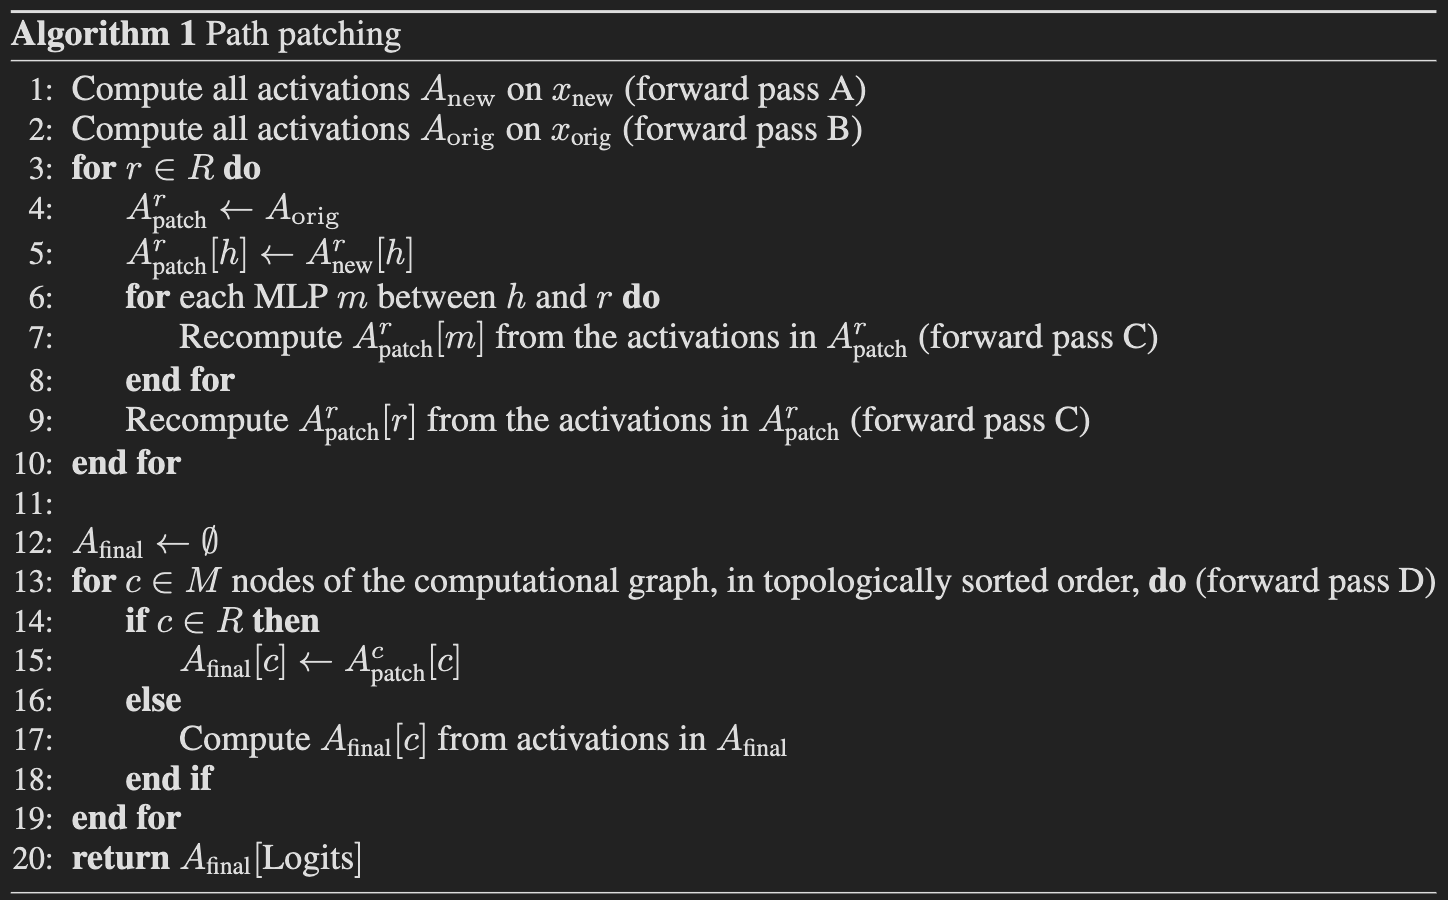

In [ ]:
## Code Path Patching Algorithm

def patch_or_freeze_sender_head(
    orig_head_vector: Float[Tensor, "batch seq head_idx d_head"],
    hook: HookPoint,
    new_cache: ActivationCache,
    orig_cache: ActivationCache,
    patch_id: Tuple[int, int]
) ->Float[Tensor, "batch seq head_idx d_head"]:

    # This is patching sender node
    orig_head_vector[...] = orig_cache[hook.name][...]
    # This is freezing all others
    if patch_id[0] == hook.layer():
        # Correctly access the tensor from new_cache using hook.name
        orig_head_vector[:, :, patch_id[1]] = new_cache[hook.name][:, :, patch_id[1]]
    return orig_head_vector

def get_path_patch_head_to_final_resid_post(
    model: HookedTransformer,
    new_dataset: IOIDataset = abc_dataset,
    orig_dataset: IOIDataset = ioi_dataset,
    patching_metric: Callable = ioi_metric_2,
    new_cache: ActivationCache = abc_cache,
    orig_cache: ActivationCache = ioi_cache
) -> Float[Tensor, "layer head"]:

    model.reset_hooks()
    result = t.zeros((model.cfg.n_layers, model.cfg.n_heads))

    # in transformer_lens, activations of attention heads are named using z, thus this function will help filter them out.
    z_name_filter = lambda name: name.endswith("z")

    # This is also the step 1
    # TODO: add code to generate new_cache and orig_cache in case they are not available.

    if new_cache is None:
        _, new_cache = model.run_with_cache(new_dataset.toks, names_filter = z_name_filter)

    if orig_cache is None:
        _, orig_cache = model.run_with_cache(orig_dataset.toks, names_filter = z_name_filter)

    # the patched_cache only contains the activation for the final residual stream (resid_post of the last layer).
    resid_post_hook_name = utils.get_act_name("resid_post", model.cfg.n_layers - 1)
    resid_post_name_filter = lambda name: name == resid_post_hook_name

    for sender_layer, sender_head_idx in tqdm(
        list(product(range(model.cfg.n_layers), range(model.cfg.n_heads)))
    ):
        # Step 2: Patch sender node, freeze all others.
        hook_fn = partial(patch_or_freeze_sender_head,
                          new_cache=new_cache,
                          orig_cache=orig_cache,
                          patch_id=(sender_layer, sender_head_idx))

        model.add_hook(z_name_filter, hook_fn)

        _, patched_cache = model.run_with_cache(
            orig_dataset.toks, names_filter=resid_post_name_filter, return_type=None
        )
        assert set(patched_cache.keys()) == {resid_post_hook_name}

        # Step 3: Run another forward pass with orig_dataset, with patched_nodes.
        # We do not need to do this because the only step left is to multiply it with the unembedding matrix.
        patched_logits = model.unembed(model.ln_final(patched_cache[resid_post_hook_name]))

        result[sender_layer, sender_head_idx] = patching_metric(patched_logits)
    return result


path_patch_head_to_final_resid_post = get_path_patch_head_to_final_resid_post(model, ioi_metric_2)


In [ ]:
fig = px.imshow(
    100 * path_patch_head_to_final_resid_post.detach().cpu().numpy(),
    title="Direct effect on logit difference",
    labels={"x": "Head", "y": "Layer", "color": "Logit diff. variation"},
    width=600,
    color_continuous_scale=px.colors.diverging.RdBu,
    color_continuous_midpoint=0.0,
)

fig.update_layout(
    coloraxis_colorbar=dict(
        ticksuffix="%"
    )
)

fig.show()


What is the interpretation of this plot? How does it compare to the equivalent plot we got from activation patching? (Remember that our metric is defined in a different way, so we should expect a sign difference between the two results.)

<details>
<summary>Some thoughts</summary>

This plot is actually almost identical to the one we got from activation patching (apart from the results being negated, because of the new metric).

This makes sense; the only reason activation patching would do something different to path patching is if the heads writing in the `Mary - John` direction had their outputs used by a later head (because this would be accounted for in activation patching, whereas path patching isolates the direct effect on the residual stream only). Since attention heads' primary purpose is to move information around the model, it's reasonable to guess that this probably isn't happening.
</details>

## Patch Patching: S-Inhibition Heads

In the first section on path patching, we performed a simple kind of patching - from the output of an attention head to the final value of the residual stream. Here we'll do something a bit more interesting, and patch from the output of one head to the input of a later head. The purpose of this is to examine exactly how two heads are composing, and what effect the composed heads have on the model's output.

We got a hint of this in the previous section, where we patched the values of the S-inhibition heads and found that they were important. But this didn't tell us which inputs to these value vectors were important; we had to make educated guesses about this based on our analysis earlier parts of the model. In path patching, we can perform a more precise test to find which heads are important.

The paper's results from path patching are shown in figure 5(b), on page 7.

In [ ]:
## Write head to head patching code

def patch_or_freeze_sender_head(
    orig_head_vector: Float[Tensor, "batch seq head_idx d_head"],
    hook: HookPoint,
    new_cache: ActivationCache,
    orig_cache: ActivationCache,
    patch_id: Tuple[int, int]
) ->Float[Tensor, "batch seq head_idx d_head"]:

    orig_head_vector[...] = orig_cache[hook.name][...]
    if patch_id[0] == hook.layer():
        orig_head_vector[:, :, patch_id[1]] = new_cache[hook.name][:, :, patch_id[1]]
    return orig_head_vector

def patch_receiver_head(
    orig_head_vector: Float[Tensor, "batch seq head_idx d_head"],
    hook: HookPoint,
    patched_cache: ActivationCache,
    receiver_heads: List[Tuple[int]]
) -> Float[Tensor, "batch seq head_idx d_head"]:
    for receiver_layer, receiver_head_idx in receiver_heads:
        if receiver_layer == hook.layer():
            orig_head_vector[:, :, receiver_head_idx] = patched_cache[hook.name][:, :, receiver_head_idx]
    return orig_head_vector


def get_path_patch_head_to_head(
    receiver_heads: List[Tuple[int]],
    receiver_input: str,
    model: HookedTransformer,
    new_dataset: IOIDataset = abc_dataset,
    orig_dataset: IOIDataset = ioi_dataset,
    patching_metric: Callable = ioi_metric_2,
    new_cache: ActivationCache = abc_cache,
    orig_cache: ActivationCache = ioi_cache
) -> Float[Tensor, "layer head"]:

    model.reset_hooks()
    # write a function which filters out the activations of the
    assert receiver_input in ["q", "k", "v"]
    receiver_head_hook_name = [utils.get_act_name(receiver_input, layer) for layer, head in receiver_heads]
    receiver_head_name_filter = lambda name: name in receiver_head_hook_name

    results = t.zeros((model.cfg.n_layers, model.cfg.n_heads))

    # write a function which filters out attn head values.
    z_name_filter = lambda name: name.endswith("z")

    if new_cache is None:
        _, new_cache = model.run_with_cache(new_dataset.toks, names_filter = z_name_filter)

    if orig_cache is None:
        _, orig_cache = model.run_with_cache(orig_dataset.toks, names_filter = z_name_filter)

    for sender_layer, sender_head_idx in tqdm(
        list(product(range(model.cfg.n_layers), range(model.cfg.n_heads)))
    ):
        # Step 2, patch sender, freeze others.
        hook_fn = partial(patch_or_freeze_sender_head,
                          new_cache=new_cache,
                          orig_cache=orig_cache,
                          patch_id=(sender_layer, sender_head_idx))

        model.add_hook(z_name_filter, hook_fn, level=1)

        _, patched_cache = model.run_with_cache(
            orig_dataset.toks, names_filter=receiver_head_name_filter, return_type=None
        )
        assert patched_cache.keys() == set(receiver_head_hook_name)

        # Step 3, run another forward pass with orig_dataset, with patched_nodes.
        hook_fn2 = partial(patch_receiver_head,
                           patched_cache = patched_cache,
                           receiver_heads = receiver_heads)

        logits = model.run_with_hooks(
            orig_dataset.toks,
            fwd_hooks = [(receiver_head_name_filter, hook_fn2)],
            return_type="logits"
        )

        results[sender_layer, sender_head_idx] = patching_metric(logits)

    return results

model.reset_hooks()
s_inhibition_value_path_patching_results = get_path_patch_head_to_head(
    receiver_heads=[(8, 6), (8, 10), (7, 9), (7, 3)],
    receiver_input="v",
    model=model,
    patching_metric=ioi_metric_2,
)


fig = px.imshow(
    100 * s_inhibition_value_path_patching_results.detach().cpu().numpy(),
    title="Direct effect on S-Inhibition Heads' values",
    labels={"x": "Head", "y": "Layer", "color": "Logit diff.<br>variation"},
    width=600,
    color_continuous_scale=px.colors.diverging.RdBu,
    color_continuous_midpoint=0.0,
)

fig.update_layout(
    coloraxis_colorbar=dict(
        ticksuffix="%"
    )
)

fig.show()



# Evaluations and Minimal Circuits

We'll start this section by replicating the paper's analysis of the **name mover heads** and **negative name mover heads**. Our previous analysis should have pretty much convinced us that these heads are copying / negatively copying our indirect object token, but the results here show this with a bit more rigour.


## Copying and Writing direction results


### writing directions results


Let's look at figure 3(c) from the paper. This plots the output of the strongest name mover and negative name mover heads against the attention probabilities for `END` attending to `IO` or `S` (color-coded).

Some clarifications:
* "Projection" here is being used synonymously with "dot product".
* We're projecting onto the name embedding, i.e. the embedding vector for the token which is being paid attention to. This is not the same as the logit diff (which we got by projecting the heads' output onto the difference between the unembedding vectors for `IO` and `S`).
    * We're doing this because the question we're trying to answer is *"does the attention head copy (or anti-copy) the names which it pays attention to?"*

In [ ]:
def scatter_embedding_vs_attn(
    attn_from_end_to_io: Float[Tensor, "batch"],
    attn_from_end_to_s: Float[Tensor, "batch"],
    projection_in_io_dir: Float[Tensor, "batch"],
    projection_in_s_dir: Float[Tensor, "batch"],
    layer: int,
    head: int,
):
    scatter(
        x=t.concat([attn_from_end_to_io, attn_from_end_to_s], dim=0),
        y=t.concat([projection_in_io_dir, projection_in_s_dir], dim=0),
        color=["IO"] * N + ["S"] * N,
        title=f"Projection of the output of {layer}.{head} along the name<br>embedding vs attention probability on name",
        title_x=0.5,
        labels={"x": "Attn prob on name", "y": "Dot w Name Embed", "color": "Name type"},
        color_discrete_sequence=["#72FF64", "#C9A5F7"],
        width=650,
    )


def calculate_and_show_scatter_embedding_vs_attn(
    layer: int,
    head: int,
    cache: ActivationCache = ioi_cache,
    dataset: IOIDataset = ioi_dataset,
):
    """
    Creates and plots a figure equivalent to 3(c) in the paper.

    This should involve computing the four 1D tensors:
        attn_from_end_to_io
        attn_from_end_to_s
        projection_in_io_dir
        projection_in_s_dir
    and then calling the scatter_embedding_vs_attn function.
    """

    # Extract the actvations of the given head.
    z = cache[utils.get_act_name("z", layer)][..., head] # shape [batch, seq, d_head]
    N = z.size(0)
    res_output = z @ model.W_O[layer, head] # multiplying with output matrix. shape [batch, seq, d_model]
    final_tok_out = res_output[t.arange(N), dataset.word_idx["end"]] # [batch, d_model]

    # Extract the directions for the IO and S objects
    io_direction = model.W_U.T[dataset.io_tokenIDs] # [batch, d_mdel]
    s_direction = model.W_U.T[dataset.s_tokenIDs] # [batch, d_model]

    # Find the attention probabilities corresponding to the end token and IO/S objects
    attn_pttrn = cache["pattern", layer][:, :, head]
    attn_from_end_to_io = attn_pttrn[t.arange(N), dataset.word_idx["end"], dataset.word_idx["IO"]]
    attn_from_end_to_s = attn_pttrn[t.arange(N), dataset.word_idx["end"], dataset.word_idx["S"]]

    # Find the projection dot products
    projection_in_io_dir = einops.einsum(final_tok_out, io_direction, "batch d_model, batch d_model -> batch")
    projection_in_s_dir = einops.einsum(final_tok_out, s_direction, "batch d_model, batch d_model -> batch")

    # Plot the scatter plot.
    scatter_embedding_vs_attn(
        attn_from_end_to_io,
        attn_from_end_to_s,
        projection_in_io_dir,
        projection_in_s_dir,
        layer,
        head,
    )



In [ ]:
calculate_and_show_scatter_embedding_vs_attn(9, 9)  # name mover head 9.9

calculate_and_show_scatter_embedding_vs_attn(11, 10)  # negative name mover head 11.10

### Copying score results

From page 6 of the paper:

> To check that the Name Mover Heads copy names generally, we studied what values are written via the heads’ OV matrix. Specifically, we first obtained the state of the residual stream at the position of each name token after the first MLP layer. Then, we multiplied this by the OV matrix of a Name Mover Head (simulating what would happen if the head attended perfectly to that token), multiplied by the unembedding matrix, and applied the final layer norm to obtain logit probabilities. We compute the proportion of samples that contain the input name token in the top 5 logits (N = 1000) and call this the copy score. All three Name Mover Heads have a copy score above 95%, compared to less than 20% for an average head.
>
> Negative Name Mover Heads ... have a large negative copy score–the copy score calculated with the negative of the OV matrix (98% compared to 12% for an average head).

Write a `get_copying_score` function below.

You could do this by indexing from the `ioi_cache`, but a much more principled alternative would be to embed all the names in the `NAMES` list and apply operations like MLPs, layernorms and OV matrices manually. This is what the solutions do.

A few notes:

* You can use `model.to_tokens` to convert the names to tokens. Remember to use `prepend_bos=False`, since you just want the tokens of names so you can embed them. Note that this function will treat the list of names as a batch of single-token inputs, which works fine for our purposes.
* You can apply MLPs and layernorms as functions, by just indexing the model's blocks (e.g. use `model.blocks[i].mlp` or `model.blocks[j].ln1` as a function). Remember that `ln1` is the layernorm that comes before attention, and `ln2` comes before the MLP.
* Remember that you need to apply MLP0 before you apply the OV matrix (which is why we omit the 0th layer in our scores). The reason for this is that ablating MLP0 has a strangely large effect in gpt2-small relative to ablating other MLPs, possibly because it's acting as an extended embedding (see [here](https://www.lesswrong.com/s/yivyHaCAmMJ3CqSyj/p/XNjRwEX9kxbpzWFWd#:~:text=GPT%2D2%20Small%E2%80%99s%20performance%20is%20ruined%20if%20you%20ablate%20MLP0) for an explanation).

In [ ]:
def get_copying_score(
    model: HookedTransformer,
    topk: int = 5,
    names: list = NAMES
)

    result = t.zeros((2, model.cfg.n_layers, model.cfg.n_heads))
    # Define the different matrics as function
    embed = model.embed
    mlp0 = model.blocks[0].mlp
    ln2 = model.blocks[0].ln2
    ln1 = model.blocks[0].ln1
    ln_final = model.ln_final
    unembed = model.unembed


    print(f"Size of NAMES: {len(NAMES)}")
    # Get the embeddings of the names list.
    NAMES_tok = model.to_tokens(NAMES, prepend_bos=False)
    NAMES_emb = embed(NAMES_tok) # [batch, 1, d_model]

    resid_after_first_mlp = NAMES_emb + mlp0(ln0(NAMES_emb)) #[batch, 1, d_model]

    # check for all heads and layers
    for layer in range(model.cfg.n_layers):
        for head in range(model.cfg.n_heads):
            W_OV = model.W_O[layer, head] @ model.W_V[layer, head]

            resid_final_pos = unembed(ln_final(W_OV @ resid_after_first_mlp)).squeeze() #[batch, d_model]
            resid_final_neg = unembed(ln_final(W_OV @ resid_after_first_mlp * -1)).squeeze() #[batch, d_model]

            tok_k_logits = topk(resid_final_pos, dim=-1, k=k).indices
            in_topk = (top_k_logits == NAMES_tok).any(-1) # check if logits match for each name,

            bot_k_logits = topk(resid_final_neg, dim=-1, k=k).indices
            in_bottomk = (bot_k_logits == NAMES_tok).any(-1) # check if logits match for each name,

            result[:, layer-1, head] = t.tensor([in_topk.float().mean(), in_bottomk.float().mean])

    return result


In [ ]:
copying_results = get_copying_scores(model)

imshow(
    copying_results,
    facet_col=0,
    facet_labels=["Positive copying scores", "Negative copying scores"],
    title="Copying scores of attention heads' OV circuits",
    width=800
)

In [ ]:
heads = {"name mover": [(9, 9), (10, 0), (9, 6)], "negative name mover": [(10, 7), (11, 10)]}

for i, name in enumerate(["name mover", "negative name mover"]):
    make_table(
        title=f"Copying Scores ({name} heads)",
        colnames=["Head", "Score"],
        cols=[
            list(map(str, heads[name])) + ["[dark_orange bold]Average"],
            [f"{copying_results[i, layer-1, head]:.2%}" for (layer, head) in heads[name]] + [f"[dark_orange bold]{copying_results[i].mean():.2%}"]
        ]
    )

## Validation of Early Heads

There are three different kinds of heads which appear early in the circuit, which can be validated by looking at their attention patterns on simple random sequences of tokens. Can you figure out which three types these are, and how to validate them in this way?

<details>
<summary>Answer</summary>

Previous token heads, induction heads, and duplicate token heads.

We can validate them all at the same time, using sequences of `n` random tokens followed by those same `n` random tokens repeated. This works as follows:

* Prev token heads, by measuring the attention patterns with an offset of one (i.e. one below the diagonal).
* Induction heads, by measuring the attention patterns with an offset of `n-1` (i.e. the second instance of a token paying attention to the token after its first instance).
* Duplicate token heads, by measuring the attention patterns with an offset of `n` (i.e. a token paying attention to its previous instance).

In all three cases, if heads score close to 1 on these metrics, it's strong evidence that they are working as this type of head.

Note, it's a leaky abstraction to say things like "head X is an induction head", since we're only observing it on a certain distribution. For instance, it's not clear what the role of induction heads and duplicate token heads is when there are no duplicates (they could in theory do something completely different).
</details>

In [ ]:
def get_random_tokens(
    model: HookedTransformer,
    seq_len: int = 100,
    batch: int = 1
) -> Int["batch, seq_len"]:

    t.manual_seed(0)
    seq = t.randint(0, model.cfg.d_vocab, (batch, seq_len))
    seq = t.cat([seq, seq], dim = -1).to(device)
    return seq

def get_attn_scores(
    model: HookedTransformer,
    seq_len: int,
    batch: int,
    head_type: Literal["duplicate", "prev", "induction"]
) -> Float["layer head"]:

    random_tokens = get_random_tokens(model=model,
                                      seq_len = seq_len,
                                      batch = batch)

    _, cache = model.run_with_cache(random_tokens, return_type=None, names_filter = lambda x: x.endswith("pattern"))
    result = t.zeros((model.cfg.n_layers, model.cfg.n_heads))

    if head_type == "duplicate":
        src_tokens_idx = range(seq_len)
        dst_tokens_idx = range(seq_len, 2*seq_len)
    elif head_type == "prev":
        src_tokens_idx = range(seq_len)
        dst_tokens_idx = range(1, seq_len+1)
    elif head_type == "induction":
        src_tokens = range(seq_len, 2 * seq_len)
        dst_tokens = range(1, seq_len+1)

    for layer in range(model.cfg.n_layers):
        for head in range(model.cfg.n_heads):
            attn_pattern = cache["pattern", layer] #[batch, heads, seqQ, seqK]
            result[layer, head] = attn_pattern[t.arange(batch), head, dst_tokens_idx, src_tokens_idx].mean().item()
    return result

def plot_early_head_validation_results(seq_len: int = 50, batch: int = 50):
    """
    Produces a plot that looks like Figure 18 in the paper.
    """
    head_types = ["duplicate", "prev", "induction"]

    results = t.stack(
        [get_attn_scores(model, seq_len, batch, head_type=head_type) for head_type in head_types]
    )

    imshow(
        results,
        facet_col=0,
        facet_labels=[
            f"{head_type.capitalize()} token attention prob.<br>on sequences of random tokens"
            for head_type in head_types
        ],
        labels={"x": "Head", "y": "Layer"},
        width=1300,
    )


model.reset_hooks()
plot_early_head_validation_results()


# Minimal Circuit

## Background: faithfulness, completeness, and minimality

The authors developed three criteria for validating their circuit explanations: faithfulness, completeness and minimality. They are defined as follows:

* **Faithful** = the circuit can perform as well as the whole model
* **Complete** = the circuit contains all nodes used to perform the task
* **Minimal** = the circuit doesn't contain nodes irrelevant to the task

If all three criteria are met, then the circuit is considered a reliable explanation for model behaviour.

Exercise - can you understand why each of these criteria is important? For each pair of criteria, is it possible for a circuit to meet them both but fail the third (and if yes, can you give examples?).

<details>
<summary>Answer</summary>

The naive circuit (containing the entire model) is trivially faithful and complete, but obviously not minimal. In general, the problem with non-minimal circuits is that they may not be mechanistically understandable, which defeats the purpose of this kind of circuit analysis.

Completeness obviously implies faithfulness, because if a node isn't involved in the task, then it can't improve the model's performance on that task.

You might initially think faithfulness implies completeness, but this actually isn't true. Backup name mover heads illustrate this point. They are used in the task, and without understanding the role they play you'll have an incorrect model of reality (e.g. you'll think ablating the name mover heads would destroy performance, which turns out not to be true). So if you define a circuit that doesn't contain backup name mover heads then it will be faithful (the backup name mover heads won't be used) but not complete.

Summary:

* **Faithful & complete, not minimal** = possible (example: naive circuit)
* **Faithful & minimal, not complete** = possible (example: circuit missing backup name mover heads)
* **Complete & minimal, not faithful** = impossible (since completeness implies faithfulness)

In the paper, the authors formalise these concepts. Faithfulness is equivalent to $|F(C) - F(M)|$ being small (where $C$ is our circuit, $M$ is the model, and $F$ is our performance metric function), and completeness is equivalent to $|F(C\backslash K) - F(M\backslash K)|$ being small **for any subset $K \subset C$** (including when $K$ is the empty set, showing that completeness implies faithfulness). Can you see how our circuit missing backup name mover heads violates this condition?

<details>
<summary>Answer</summary>

It violates the condition when $K$ is the set of name mover heads. $C \backslash K$ performs worse than $M \backslash K$, because the latter contains backup name mover heads while the former has lost its name mover heads ***and*** backup name mover heads.
</details>
</details>

How do we ablate? We could use zero-ablation, but this actually has some non-obvious problems. To explain why intuitively, heads might be "expecting" non-zero input, and setting the input to zero is essentially an arbitrary choice which takes it off distribution. You can think of this as adding a bias term to this head, which might mess up subsequent computation and lead to noisy results. We could also use mean-ablation (i.e. set a head's output to its average output over `ioi_dataset`), but the problem here is that taking the mean over this dataset might contain relevant information for solving the IOI task. For example the `is_duplicated` flag which gets written to `S2` will be present for all sequences, so averaging won't remove this information.

Can you think of a way to solve this problem? After you've considered this, you can use the dropdown below to see how the authors handled this.

<details>
<summary>Answer</summary>

We ablate with the mean of the ABC dataset rather than the IOI dataset. This removes the problem of averages still containing relevant information from solving the IOI task.

</details>

One other complication - the sentences have different templates, and the positions of tokens like `S` and `IO` are not consistent across these templates (we avoided this problem in previous exercises by choosing a very small set of sentences, where all the important tokens had the same indices). An example of two templates with different positions:

```
"Then, [B] and [A] had a long argument and after that [B] said to [A]"
"After the lunch [B] and [A] went to the [PLACE], and [B] gave a [OBJECT] to [A]"
```

Can you guess what the authors did to solve this problem?

<details>
<summary>Answer</summary>

They took the mean over each template rather than over the whole dataset, and used these values to ablate with.

In other words, when they performed ablation by patching in the output of a head (which has shape `(batch, seq, d_model)`), the value patched into the `(i, j, k)`-th element of this tensor would be the average value of the `k`-th element of the vector at sequence position `j`, for all sentences with the same template as the `i`-th sentence in the batch.
</details>

In [ ]:
CIRCUIT = {
    "name mover": [(9, 9), (10, 0), (9, 6)],
    "backup name mover": [(10, 10), (10, 6), (10, 2), (10, 1), (11, 2), (9, 7), (9, 0), (11, 9)],
    "negative name mover": [(10, 7), (11, 10)],
    "s2 inhibition": [(7, 3), (7, 9), (8, 6), (8, 10)],
    "induction": [(5, 5), (5, 8), (5, 9), (6, 9)],
    "duplicate token": [(0, 1), (0, 10), (3, 0)],
    "previous token": [(2, 2), (4, 11)],
}

SEQ_POS_TO_KEEP = {
    "name mover": "end",
    "backup name mover": "end",
    "negative name mover": "end",
    "s2 inhibition": "end",
    "induction": "S2",
    "duplicate token": "S2",
    "previous token": "S1+1",
}

To be clear, the things that we'll be mean-ablating are:

* Every head not in the `CIRCUIT` dict
* Every sequence position for the heads in `CIRCUIT` dict, except for the sequence positions given by the `SEQ_POS_TO_KEEP` dict

And we'll be mean-ablating by replacing a head's output with the mean output for `abc_dataset`, over all sentences with the same template as the sentence in the batch. You can access the templates for a dataset using the `dataset.groups` attribute, which returns a list of tensors (each one containing the indices of sequences in the batch sharing the same template).

In [ ]:
def get_heads_and_posns_to_keep(
    means_dataset: IOIDataset,
    model: HookedTransformer,
    circuit: dict[str, list[tuple[int, int]]],
    seq_pos_to_keep: dict[str, str]
) -> dict[int, Bool["batch seq head"]]:
    """
    Generates a mask indicating which heads and sequence positions to keep (i.e., not ablate).
    This mask is based on the defined circuit and specific sequence positions for each head type.

    Args:
        means_dataset (IOIDataset): The dataset used for computing means and extracting word indices.
        model (HookedTransformer): The HookedTransformer model.
        circuit (dict[str, list[tuple[int, int]]]): A dictionary defining the circuit,
            mapping head types (e.g., "name mover") to a list of (layer, head_idx) tuples.
        seq_pos_to_keep (dict[str, str]): A dictionary mapping head types to the
            string identifier of the sequence position to keep (e.g., "end", "S2").

    Returns:
        dict[int, Bool["batch seq head"]]: A dictionary where keys are layer indices
            and values are boolean masks. Each mask has shape (batch, seq_len, n_heads),
            with True indicating positions that should *not* be ablated.
    """
    heads_and_posns_to_keep = {}
    batch_size, seq_len, n_heads = len(means_dataset), means_dataset.max_len, model.cfg.n_heads

    for layer in range(model.cfg.n_layers):
        # Initialize a mask of False (meaning ablate by default)
        mask = t.zeros((batch_size, seq_len, n_heads), dtype=t.bool, device=model.cfg.device)

        for head_name, head_data in circuit.items():
            # Get the sequence position identifier for this head type
            seq_ids_to_keep = seq_pos_to_keep[head_name]
            # Get the actual token indices for these positions across the batch
            indices = means_dataset.word_idx[seq_ids_to_keep]

            # Iterate through the (layer, head_idx) pairs defined for this head type
            for layer_idx, head_idx in head_data:
                if layer_idx == layer:
                    # Set the mask to True for the specified head and its corresponding sequence positions
                    mask[t.arange(batch_size), indices, head_idx] = True

        heads_and_posns_to_keep[layer] = mask

    return heads_and_posns_to_keep


def compute_means_by_template(
    means_dataset: IOIDataset,
    model: HookedTransformer,
) -> Float[Tensor, "layer batch seq head d_head"]:
    """
    Computes the mean activation (z-value) for each head, per template group.
    This is used for mean-ablation, where activations are replaced by the average
    of activations from the ABC dataset for the same template.

    Args:
        means_dataset (IOIDataset): The dataset (typically ABC dataset) to compute means from.
        model (HookedTransformer): The HookedTransformer model.

    Returns:
        Float[Tensor, "layer batch seq head d_head"]: A tensor containing the mean z-values.
            The batch dimension here effectively stores a unique mean for each original
            prompt (which is then used for all prompts belonging to the same template group).
    """
    # generate the cache for all the prompts in all the templates
    _, cache = model.run_with_cache(
        means_dataset.toks.long(), # Ensure tokens are long type
        return_type=None,
        names_filter=lambda x: x.endswith("z"), # Filter for attention head outputs
    )

    # Create a tensor to store means
    # Shape: [n_layers, batch_size, seq_len, n_heads, d_head]
    n_layers, n_heads, d_head = model.cfg.n_layers, model.cfg.n_heads, model.cfg.d_head
    batch_size, seq_len = len(means_dataset), means_dataset.max_len
    means = t.zeros((n_layers, batch_size, seq_len, n_heads, d_head), device=model.cfg.device)

    # Calculate means by template group
    for layer in range(n_layers):
        z_this_layer = cache[utils.get_act_name("z", layer)] # shape [batch, seq, head, d_head]
        for group_indices in means_dataset.groups:
            # For each template group, compute the mean z-value
            z_this_group = z_this_layer[group_indices] # Activations for this template group
            mean_z_this_group = einops.reduce(
                z_this_group,
                "batch seq head d_head -> seq head d_head", # Reduce over the batch dimension
                "mean"
            )
            # Assign the computed mean back to all prompts within this template group
            means[layer, group_indices] = mean_z_this_group

    return means

def hook_fn_mask_z(
    head_vector: Float[Tensor, "batch seq head d_head"],
    hook: HookPoint,
    heads_and_posns_to_keep: dict[int, Bool["batch seq head"]],
    means: Float[Tensor, "layer batch seq head d_head"],
) -> Float[Tensor, "batch seq head d_head"]:
    """
    Hook function to perform mean ablation. It replaces the 'z' (attention head output)
    activations with pre-computed means for positions and heads not specified to be kept
    by the circuit.

    Args:
        head_vector (Float[Tensor, "batch seq head d_head"]): The current attention head
            output activation.
        hook (HookPoint): The hook point object, providing context like the current layer.
        heads_and_posns_to_keep (dict[int, Bool["batch seq head"]]): A mask indicating
            which head outputs and sequence positions to preserve.
        means (Float[Tensor, "layer batch seq head d_head"]): Pre-computed mean activations
            (from the ABC dataset) to use for ablation.

    Returns:
        Float[Tensor, "batch seq head d_head"]:
            The modified head_vector with ablated (mean-patched) values.
    """
    # Get the mask for the current layer, and add a d_head=1 dimension for broadcasting
    mask_for_this_layer = heads_and_posns_to_keep[hook.layer()].unsqueeze(-1)

    # Replace head_vector values with means where the mask is False (i.e., ablate these)
    # Keep original head_vector values where the mask is True
    return t.where(mask_for_this_layer, head_vector, means[hook.layer()])

def add_mean_ablation_hook(
    model: HookedTransformer,
    means_dataset: IOIDataset,
    circuit: dict[str, list[tuple[int, int]]] = CIRCUIT,
    seq_pos_to_keep: dict[str, str] = SEQ_POS_TO_KEEP,
    is_permanent: bool = True,
) -> HookedTransformer:
    """
    Adds a permanent hook to the model to perform mean ablation based on a specified circuit.
    This hook replaces attention head outputs (`z` activations) with pre-computed means
    for heads and positions that are *not* part of the minimal circuit.

    Args:
        model (HookedTransformer): The model to which the hook will be added.
        means_dataset (IOIDataset): The dataset (typically ABC dataset) used to compute
            the mean activations for ablation.
        circuit (dict[str, list[tuple[int, int]]], optional): A dictionary defining the
            minimal circuit, specifying which heads to keep. Defaults to CIRCUIT.
        seq_pos_to_keep (dict[str, str], optional): A dictionary mapping head types to
            the sequence position to keep. Defaults to SEQ_POS_TO_KEEP.
        is_permanent (bool, optional): If True, the hook is permanent. Defaults to True.

    Returns:
        HookedTransformer: The model with the ablation hook added.
    """
    # Compute means by template for ablation values
    means_by_template = compute_means_by_template(means_dataset, model)
    # Determine which heads and positions to keep based on the circuit
    heads_and_posns_to_keep = get_heads_and_posns_to_keep(means_dataset, model, circuit, seq_pos_to_keep)

    # Reset any existing hooks before adding new ones
    model.reset_hooks(including_permanent=True)

    # Create a partial function for the hook, pre-filling the computed means and mask
    hook_fn = partial(
        hook_fn_mask_z,
        heads_and_posns_to_keep=heads_and_posns_to_keep,
        means=means_by_template
    )

    # Add the hook to all 'z' activations (attention head outputs)
    model.add_hook(lambda name: name.endswith("z"), hook_fn, is_permanent=is_permanent)

    return model

In [ ]:
model = add_mean_ablation_hook(
    model,
    means_dataset=abc_dataset,
    circuit=CIRCUIT,
    seq_pos_to_keep=SEQ_POS_TO_KEEP,
)
ioi_logits_minimal = model(ioi_dataset.toks)

print(f"""
Avg logit diff (IOI dataset, using entire model): {logits_to_ave_logit_diff_2(ioi_logits_original):.4f}
Avg logit diff (IOI dataset, only using circuit): {logits_to_ave_logit_diff_2(ioi_logits_minimal):.4f}
""")

These are the sets that are obtained by greedy extraction of minimility sets as explained in the algrithm in section 4.2 of the paper

In [ ]:
K_FOR_EACH_COMPONENT = {
    (9, 9): set(),
    (10, 0): {(9, 9)},
    (9, 6): {(9, 9), (10, 0)},
    (10, 7): {(11, 10)},
    (11, 10): {(10, 7)},
    (8, 10): {(7, 9), (8, 6), (7, 3)},
    (7, 9): {(8, 10), (8, 6), (7, 3)},
    (8, 6): {(7, 9), (8, 10), (7, 3)},
    (7, 3): {(7, 9), (8, 10), (8, 6)},
    (5, 5): {(5, 9), (6, 9), (5, 8)},
    (5, 9): {(11, 10), (10, 7)},
    (6, 9): {(5, 9), (5, 5), (5, 8)},
    (5, 8): {(11, 10), (10, 7)},
    (0, 1): {(0, 10), (3, 0)},
    (0, 10): {(0, 1), (3, 0)},
    (3, 0): {(0, 1), (0, 10)},
    (4, 11): {(2, 2)},
    (2, 2): {(4, 11)},
    (11, 2): {(9, 9), (10, 0), (9, 6)},
    (10, 6): {(9, 9), (10, 0), (9, 6), (11, 2)},
    (10, 10): {(9, 9), (10, 0), (9, 6), (11, 2), (10, 6)},
    (10, 2): {(9, 9), (10, 0), (9, 6), (11, 2), (10, 6), (10, 10)},
    (9, 7): {(9, 9), (10, 0), (9, 6), (11, 2), (10, 6), (10, 10), (10, 2)},
    (10, 1): {(9, 9), (10, 0), (9, 6), (11, 2), (10, 6), (10, 10), (10, 2), (9, 7)},
    (11, 9): {(9, 9), (10, 0), (9, 6), (9, 0)},
    (9, 0): {(9, 9), (10, 0), (9, 6), (11, 9)},
}

Below is the code that will create plot similar to figure 7 in the paper.

In [ ]:
def plot_minimal_set_results(minimality_scores: dict[tuple[int, int], float]):
    """
    Plots the minimality results, in a way resembling figure 7 in the paper.

    minimality_scores:
        dict with elements like (9, 9): minimality score for head 9.9 (as described
        in section 4.2 of the paper)
    """

    CIRCUIT_reversed = {head: k for k, v in CIRCUIT.items() for head in v}
    colors = [CIRCUIT_reversed[head].capitalize() + " head" for head in minimality_scores.keys()]
    color_sequence = [px.colors.qualitative.Dark2[i] for i in [0, 1, 2, 5, 3, 6]] + ["#BAEA84"]

    bar(
        list(minimality_scores.values()),
        x=list(map(str, minimality_scores.keys())),
        labels={"x": "Attention head", "y": "Change in logit diff", "color": "Head type"},
        color=colors,
        template="ggplot2",
        color_discrete_sequence=color_sequence,
        bargap=0.02,
        yaxis_tickformat=".0%",
        legend_title_text="",
        title="Plot of minimality scores (as percentages of full model logit diff)",
        width=800,
        hovermode="x unified",
    )

In [ ]:
def get_score(
    model: HookedTransformer,
    ioi_dataset: IOIDataset,
    abc_dataset: IOIDataset,
    K: set[tuple[int, int]],
    C: set[tuple[int, int]] = CIRCUIT
):
    C_excl_K = {k: [head for head in v if head not in K] for k, v in C.items()}
    model = add_mean_ablation_hook(model, abc_dataset, C_excl_K, SEQ_POS_TO_KEEP)
    logits = model(ioi_dataset.toks)
    score = logits_to_ave_logit_diff_2(logits, ioi_dataset).item()

    return score

def get_minimality_score(
    model: HookedTransformer,
    ioi_dataset: IOIDataset,
    abc_dataset: IOIDataset,
    v: tuple[int, int],
    K: set[tuple[int, int]],
) -> float:
    assert v not in K
    K_union_v = K | {v}
    C_excl_K_score = get_score(model, ioi_dataset, abc_dataset, K, C)
    C_excl_Kv_score = get_score(model, ioi_dataset, abc_dataset, K_union_v, C)

    return abs(C_excl_K_score - C_excl_Kv_score)


def get_all_minimality_scores(
    model: HookedTransformer,
    ioi_dataset: IOIDataset = ioi_dataset,
    abc_dataset: IOIDataset = abc_dataset,
    k_for_each_component: dict = K_FOR_EACH_COMPONENT,
) -> dict[tuple[int, int], float]:
    model.reset_hooks()
    logits = model(ioi_dataset.toks)
    full_circuit_score = logits_to_ave_logit_diff_2(logits,ioi_dataset).item()

    # Get all minimality scores, using the `get_minimality_score` function
    minimality_scores = {}
    for v, K in tqdm(k_for_each_component.items()):
        score = get_minimality_score(model, ioi_dataset, abc_dataset, v, K)
        minimality_scores[v] = score / full_circuit_score

    model.reset_hooks(including_permanent=True)

    return minimality_scores



In [ ]:
plot_minimal_set_results(minimality_scores)